In [1]:
library(tidyverse)
library(corrplot)
library(ppcor)
library(astsa)
library(funtimes)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Loading required package: MASS


Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select


Warning message:
"package 'astsa' was built under R version 4.5.3"
Warning message:
"package 'funtimes' was built under R version 4.5.3"


## Duomenys

In [2]:
data <- read.csv(file.path("..", "..", "python", "datasets_prep", "dm_project_dataset.csv"), sep = ',')
data$observationTime <- as.Date(data$observationTime)

data <- data %>%
  dplyr::select(observationTime, airTemperature, feelsLikeTemperature_fixed, seaLevelPressure, relativeHumidity, xgb_cloudCover, 
  windSpeed_fixed, windGust_fixed, windDirection_fixed, absorbing_aerosol_index, NO2_column_number_density, stratospheric_NO2_column_number_density,
  NO2_slant_column_number_density, tropopause_pressure, H2O_column_number_density, BrO, NO2, O3, dust, pm2p5, pm10, sia, nmvoc, nh3, pans, everything())

dim(data)

[1] 2772   31

In [3]:
colnames(data)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "BrO_Error"                              
[27] "NO2_Error"                              
[28] "O3_Error"                               
[29] "tp"                                     
[30] "t2m"                                    
[31] "missforest_precipitation"

In [4]:
head(data, 5)

,observationTime,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,⋯,sia,nmvoc,nh3,pans,BrO_Error,NO2_Error,O3_Error,tp,t2m,missforest_precipitation
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-07-01,11.29583,10.93333,1010.638,72.79167,89.37500,3.762500,13.9,356,-1.0162473,⋯,0.4123398,2.292138,0.1059741,1.174715,1.489699e+13,2.984735e+14,0.8230156,14.65335800,12.97028,9.1
2,2018-07-02,10.86667,10.42917,1006.663,94.00000,91.50000,2.516667,7.0,327,-0.8006216,⋯,0.9462600,3.792921,0.1984277,1.935448,1.611675e+13,2.865718e+14,0.7565302,6.47595700,14.77985,11.9
3,2018-07-03,13.38750,13.38750,1008.454,90.04167,89.37500,2.537500,8.3,271,-0.6212348,⋯,0.6769881,2.332084,0.1188589,1.787800,1.499280e+13,3.356409e+14,1.6245888,9.60731700,15.96597,10.0
4,2018-07-04,13.59167,13.59167,1009.237,88.29167,88.33333,2.358333,8.7,288,-0.6591799,⋯,0.8331606,2.113538,0.3611570,1.201320,1.430855e+13,3.289718e+14,0.7592764,0.01330757,18.01572,13.9
5,2018-07-05,16.29167,16.29167,1008.079,70.20833,66.00000,1.283333,6.1,293,-1.0102344,⋯,0.7374821,2.267631,0.3165334,1.206750,1.583584e+13,3.421961e+14,0.8920967,0.00000000,19.04031,0.0


In [5]:
colnames(data)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "BrO_Error"                              
[27] "NO2_Error"                              
[28] "O3_Error"                               
[29] "tp"                                     
[30] "t2m"                                    
[31] "missforest_precipitation"

Visi duomenys išskyrus taršos rodiklių paklaidas

In [6]:
data_clean <- data %>%
    mutate(tp_lag = lag(tp, 1)) %>%
    mutate(tp_error = abs(tp_lag - missforest_precipitation)) %>%
    dplyr::select(-c('BrO_Error', 'NO2_Error', 'O3_Error')) %>%
    na.omit()

In [7]:
dim(data_clean)

[1] 2771   30

## Oro taršos elementų įtaką kritulių prognozavimo tikslumui

### Paklaidos kiekvienai dienai

In [8]:
x <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-missforest_precipitation, -tp, -t2m, -tp_lag, -tp_error)

cor_rez_day <- cor(x, data_clean$tp_error, use = "complete.obs", method = "spearman") 
cor_rez_day

airTemperature,0.03609559
feelsLikeTemperature_fixed,0.02175072
seaLevelPressure,-0.48334406
relativeHumidity,0.37082204
xgb_cloudCover,0.44298572
windSpeed_fixed,0.18308086
windGust_fixed,0.25152379
windDirection_fixed,0.04536711
absorbing_aerosol_index,-0.04455689
NO2_column_number_density,0.03071434
stratospheric_NO2_column_number_density,0.04573508


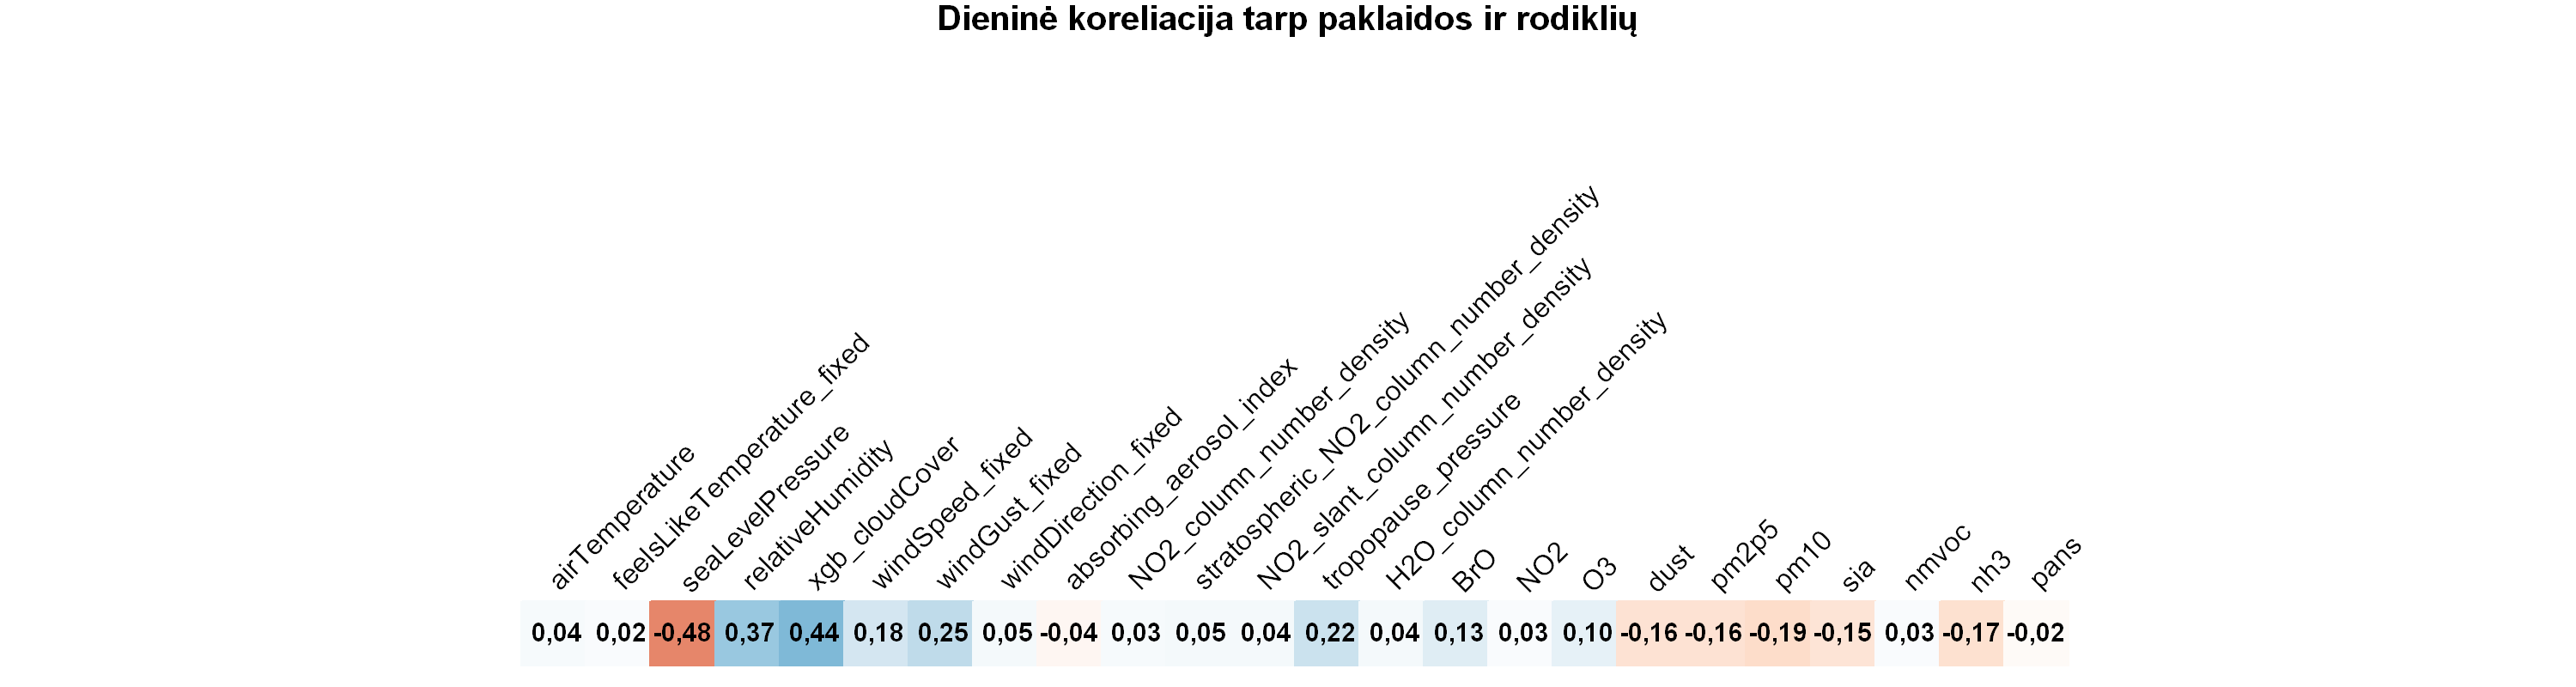

In [9]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)

plot_corr_1 <- as.matrix(t(cor_rez_day))
rownames(plot_corr_1) <- ""

# png(filename = "corr_heatmap_1.png", width = 17, height = 4.5, units = "in", res = 300)

options(OutDec = ",")
corrplot(plot_corr_1, method = 'color', addCoef.col = "black", tl.srt = 45, tl.col = 'black', tl.pos = 't', number.cex = 0.9, cl.pos = 'n', title = "Dieninė koreliacija tarp paklaidos ir rodiklių", mar = c(0,0,1,0))
options(OutDec = ".")

# dev.off()

In [10]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

col_names <- c(
  "airTemperature" = "Oro temperatūra",
  "feelsLikeTemperature_fixed" = "Juntamoji temperatūra",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Santykinis oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2 VCD T",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2 VCD G",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "pm2p5" = "PM2,5",
  "pm10" = "PM10",
  "sia" = "PM2,5 SIA",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pans" = "PAN"
)

rownames(cor_rez_day) <- col_names

part1 <- as.matrix(cor_rez_day[1:8, , drop = FALSE])
part2 <- as.matrix(cor_rez_day[9:16, , drop = FALSE])
part3 <- as.matrix(cor_rez_day[17:24, , drop = FALSE])

colnames(part1) <- "Paklaida"; colnames(part2) <- "Paklaida"; colnames(part3) <- "Paklaida"

width_inch = 14 / 2.54
height_inch = width_inch * 0.6

png(filename = "corr_heatmap_1.png", width = width_inch, height = height_inch, units = "in", res = 300)
layout(matrix(c(1, 2, 3), 1, 3))
par(mfrow = c(1, 3), oma = c(0, 0, 4, 0))

options(OutDec = ",")

corrplot(part1, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part2, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part3, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)

mtext("Koreliacija tarp dieninės ECMWF paklaidos ir rodiklių", side = 3, line = 2, outer = TRUE, cex = 0.85, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_1105798790 
                    2

### Paklaidos mėnesiui

In [11]:
data_by_month <- data_clean %>%
    dplyr::select(-t2m, -tp, -tp_lag) %>%
    group_by(year = year(observationTime), month = month(observationTime)) %>%
    summarise(across(where(is.numeric), ~mean(., na.rm = TRUE)), .groups = "drop")
head(data_by_month)

year,month,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,⋯,O3,dust,pm2p5,pm10,sia,nmvoc,nh3,pans,missforest_precipitation,tp_error
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2018,7,19.782222,19.83361111,1011.621,77.39444,61.43400,1.985833,9.106667,153.3000,⋯,325.8890,1.06237442,4.601026,5.652042,1.548626,3.585722,0.19122389,1.6584937,3.6733333,2.6259517
2018,8,19.148656,19.12238514,1016.927,71.29839,41.00312,2.005951,9.129032,190.0000,⋯,304.8510,0.09325709,4.798764,6.347528,2.258098,3.150768,0.51960494,1.6170481,1.7419355,2.7504680
2018,9,14.635694,14.21180556,1018.335,73.81667,50.09821,2.285833,9.126667,195.6333,⋯,297.2015,2.23112997,7.357725,11.413385,3.133960,3.261975,0.60311948,1.4149473,1.1200000,1.0561986
2018,10,8.083360,6.73062903,1017.771,82.20124,50.89922,2.825586,9.354839,174.8710,⋯,294.6680,0.29404332,6.242818,8.690252,3.243211,3.197375,0.29334225,1.0552586,1.3290323,0.5587336
2018,11,2.051250,-0.05652778,1027.381,91.02778,86.08711,2.671944,7.813333,155.7000,⋯,310.4006,1.48851305,8.132359,10.514413,4.479328,3.383899,0.07620617,1.0289202,0.5733333,0.5433934
2018,12,-1.481586,-4.78010753,1016.517,94.35215,94.00801,2.848253,8.132258,161.2581,⋯,318.7455,0.04485326,4.724880,6.197183,2.343671,4.634385,0.02553789,0.9796066,2.3741935,1.1422593


In [12]:
x_monthly <- data_by_month %>%
  dplyr::select(where(is.numeric)) %>%
  dplyr::select(-year, -month, -missforest_precipitation, -tp_error)

cor_rez_month <- cor(x_monthly, data_by_month$tp_error, use = "complete.obs", method = "spearman") 
cor_rez_month

airTemperature,0.64046823
feelsLikeTemperature_fixed,0.63139035
seaLevelPressure,-0.49695811
relativeHumidity,-0.26641185
xgb_cloudCover,-0.26032808
windSpeed_fixed,-0.39767479
windGust_fixed,0.04552495
windDirection_fixed,-0.04290492
absorbing_aerosol_index,-0.21925466
NO2_column_number_density,0.37383341
stratospheric_NO2_column_number_density,0.60033445


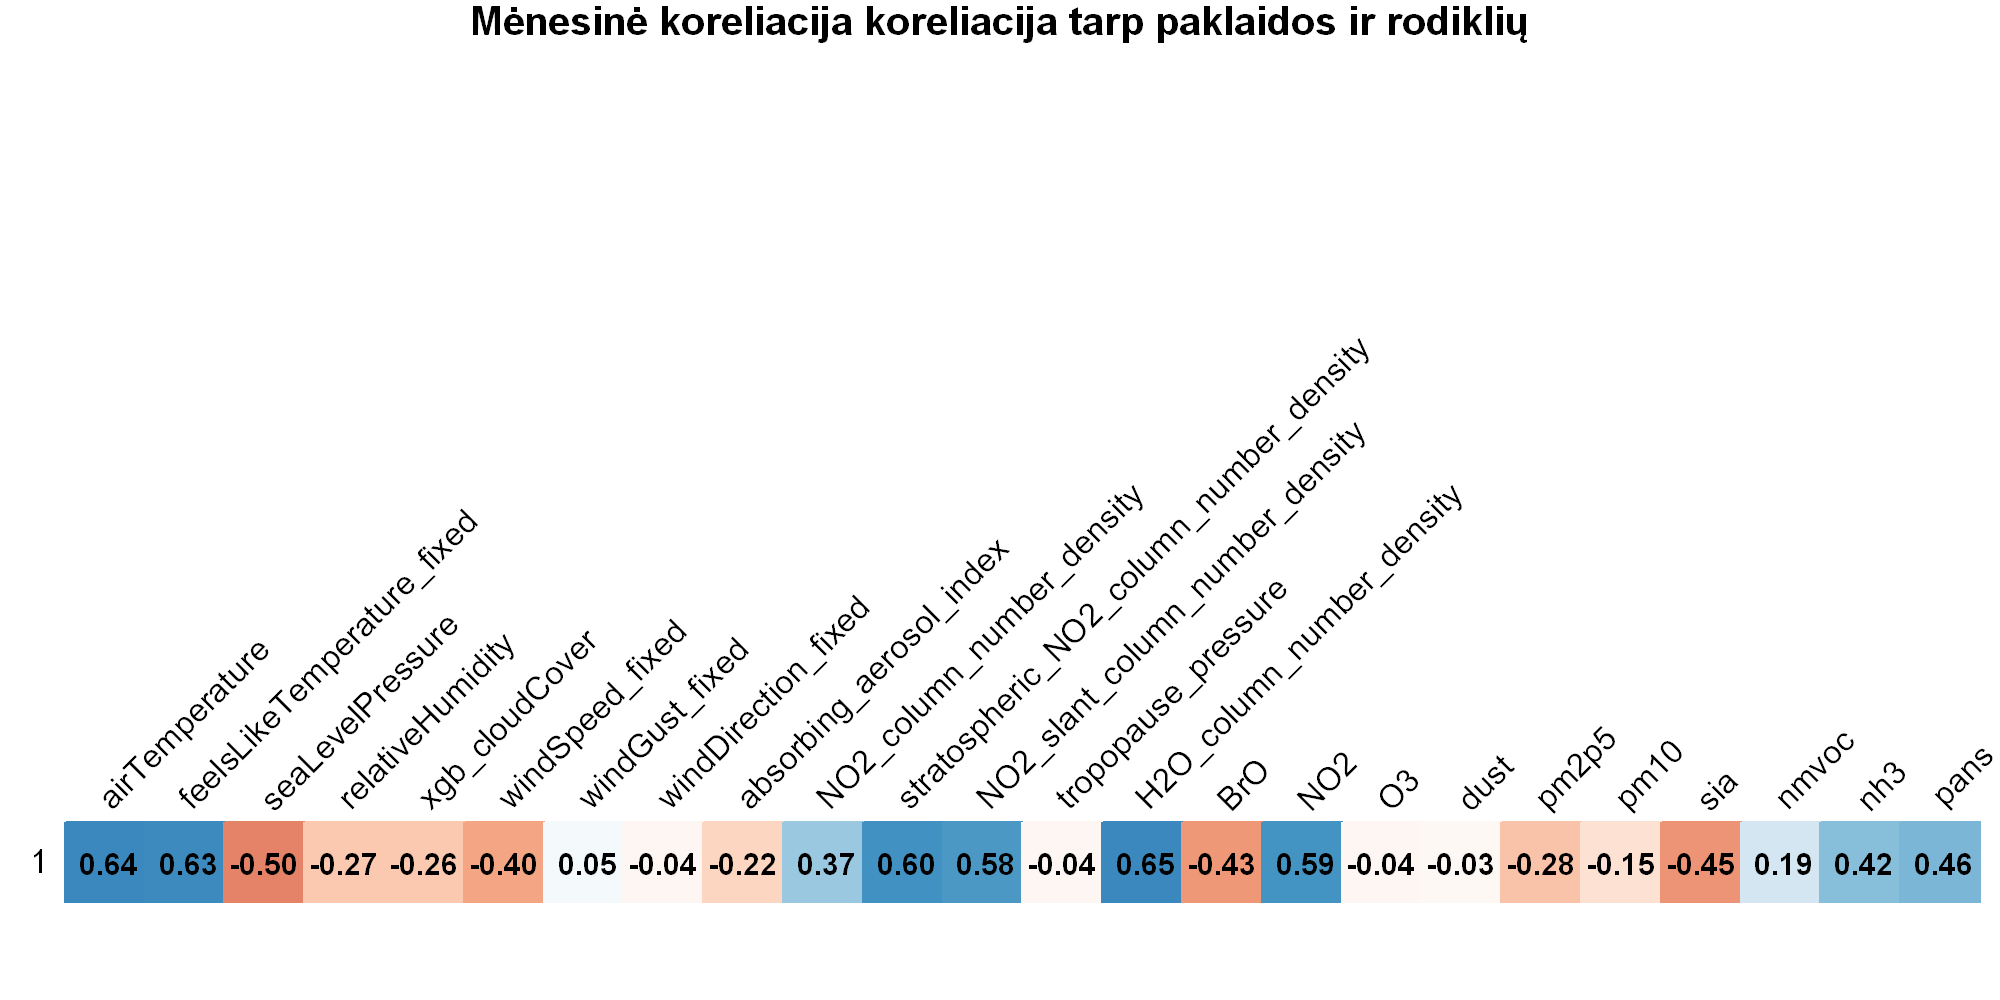

In [13]:
corrplot(t(cor_rez_month), method = 'color', addCoef.col = "black", tl.srt = 45, tl.col = 'black', number.cex = 0.9, cl.pos = 'n', title = "Mėnesinė koreliacija koreliacija tarp paklaidos ir rodiklių", mar = c(0,0,1,0))

In [14]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

rownames(cor_rez_day) <- col_names
rownames(cor_rez_month) <- col_names

part_day1 <- as.matrix(cor_rez_day[1:8, , drop = FALSE])
part_day2 <- as.matrix(cor_rez_day[9:16, , drop = FALSE])
part_day3 <- as.matrix(cor_rez_day[17:24, , drop = FALSE])

part_month1 <- as.matrix(cor_rez_month[1:8, , drop = FALSE])
part_month2 <- as.matrix(cor_rez_month[9:16, , drop = FALSE])
part_month3 <- as.matrix(cor_rez_month[17:24, , drop = FALSE])

colnames(part_day1) <- "Dienos"; colnames(part_day2) <- "Dienos"; colnames(part_day3) <- "Dienos"
colnames(part_month1) <- "Mėnesio"; colnames(part_month2) <- "Mėnesio"; colnames(part_month3) <- "Mėnesio"

part1 <- cbind(part_day1, part_month1)
part2 <- cbind(part_day2, part_month2)
part3 <- cbind(part_day3, part_month3)

width_inch = 14 / 2.54
height_inch = width_inch * 0.6

png(filename = "corr_heatmap_NEW1.png", width = width_inch, height = height_inch, units = "in", res = 300)

par(mfrow = c(1, 3), oma = c(0, 0, 4, 0))

options(OutDec = ",")

corrplot(part1, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part2, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part3, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)

mtext("Koreliacija tarp dieninės ir mėnesinės ECMWF paklaidos ir rodiklių", side = 3, line = 2, outer = TRUE, cex = 0.75, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_1507637584 
                    2

In [ ]:
col_names_simple <- c(
  "airTemperature" = "Oro temperatūra",
  "feelsLikeTemperature_fixed" = "Juntamoji temp.",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Sant. oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2(Tr) VCD",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2(Go) VCD",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "pm2p5" = "PM2.5",
  "pm10" = "PM10",
  "sia" = "PM2.5 SIA",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pans" = "PAN"
)

labels_expr <- list(
  expression(Oro~temperatūra),
  expression(Juntamoji~temp.),
  expression(Slėgis~jūros~lygyje),
  expression(Sant.~oro~drėgnis),
  expression(Debesuotumas),
  expression(Vėjo~greitis),
  expression(Vėjo~gūsis),
  expression(Vėjo~kryptis),
  expression(AAI),
  expression(NO[2](Tr)~VCD),
  expression(Stratosferos~NO[2]~VCD),
  expression(NO[2]~SCD),
  expression(Tropopauzės~slėgis),
  expression(H[2]*O),
  expression(BrO~VCD),
  expression(NO[2](Go)~VCD),
  expression(O[3]~VCD),
  expression(Dulkės),
  expression(PM[2.5]),
  expression(PM[10]),
  expression(PM[2.5]~SIA),
  expression(NMVOC),
  expression(NH[3]),
  expression(PAN)
)

add_row_labels <- function(labels, n = 8, cex = 0.82) {
  usr <- par("usr")
  x <- usr[1]
  for (i in 1:n) {
    y <- n + 1 - i
    text(x = x, y = y, labels = labels[[i]],
         xpd = NA, adj = c(1, 0.5), cex = cex, col = "black")
  }
}

add_col_headers <- function() {
  usr <- par("usr")
  text(x = 0.90, y = par("usr")[4] + 0.1, labels = "Dienos",
       xpd = NA, adj = c(0.5, 0), cex = 0.72, col = "black")
  text(x = 2.10, y = par("usr")[4] + 0.1, labels = "Mėnesio",
       xpd = NA, adj = c(0.5, 0), cex = 0.72, col = "black")
}

rownames(cor_rez_day)   <- unname(col_names_simple)
rownames(cor_rez_month) <- unname(col_names_simple)

part_day1 <- as.matrix(cor_rez_day[1:8,   , drop = FALSE])
part_day2 <- as.matrix(cor_rez_day[9:16,  , drop = FALSE])
part_day3 <- as.matrix(cor_rez_day[17:24, , drop = FALSE])

part_month1 <- as.matrix(cor_rez_month[1:8,   , drop = FALSE])
part_month2 <- as.matrix(cor_rez_month[9:16,  , drop = FALSE])
part_month3 <- as.matrix(cor_rez_month[17:24, , drop = FALSE])

colnames(part_day1) <- "Dienos"; colnames(part_day2) <- "Dienos"; colnames(part_day3) <- "Dienos"
colnames(part_month1) <- "Mėnesio"; colnames(part_month2) <- "Mėnesio"; colnames(part_month3) <- "Mėnesio"

part1 <- cbind(part_day1, part_month1)
part2 <- cbind(part_day2, part_month2)
part3 <- cbind(part_day3, part_month3)

width_inch <- 14 / 2.54
height_inch <- width_inch * 0.6

png(filename = "corr_heatmap_NEW2.png", width = width_inch, height = height_inch,
    units = "in", res = 300)

par(mfrow = c(1, 3),
    mar = c(2, 8, 3, 1),
    oma = c(0, 0, 2, 0))

options(OutDec = ",")

corrplot(part1, method = 'color', addCoef.col = "black", tl.col = 'black',
         tl.srt = 0, tl.pos = 'n', cl.pos = 'n',
         number.cex = 0.8, tl.cex = 0.8, mar = c(2, 8, 3, 1))
add_row_labels(labels_expr[1:8])
add_col_headers()

corrplot(part2, method = 'color', addCoef.col = "black", tl.col = 'black',
         tl.srt = 0, tl.pos = 'n', cl.pos = 'n',
         number.cex = 0.8, tl.cex = 0.8, mar = c(2, 8, 3, 1))
add_row_labels(labels_expr[9:16])
add_col_headers()

corrplot(part3, method = 'color', addCoef.col = "black", tl.col = 'black',
         tl.srt = 0, tl.pos = 'n', cl.pos = 'n',
         number.cex = 0.8, tl.cex = 0.8, mar = c(2, 8, 3, 1))
add_row_labels(labels_expr[17:24])
add_col_headers()

mtext("Koreliacija tarp dieninės ir mėnesinės ECMWF paklaidos ir rodiklių",
      side = 3, line = -0.5, outer = TRUE, cex = 0.75, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_1120843675 
                    2

## Koreliacija
### Koreliacija tarp visų kintamųjų

In [16]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

In [17]:
numeric_columns <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-tp, -tp_lag, -t2m, -tp_error)
    
corr <- cor(numeric_columns, use = "complete.obs", method = "spearman") 
View(corr)

,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,NO2_column_number_density,⋯,NO2,O3,dust,pm2p5,pm10,sia,nmvoc,nh3,pans,missforest_precipitation
airTemperature,1.000000000,0.995824697,-0.07042726,-0.48802994,-0.51155906,-0.28803980,-0.018803249,-0.09213059,-0.243054827,0.11357850,⋯,0.777419698,-0.30016130,0.3738084,0.103412156,0.22934763,-0.007459254,0.03232202,0.704016946,0.43242763,-0.083054679
feelsLikeTemperature_fixed,0.995824697,1.000000000,-0.04326567,-0.48757031,-0.51839092,-0.34833509,-0.070698683,-0.10144099,-0.241801642,0.11521276,⋯,0.782389129,-0.29976783,0.3803067,0.104530481,0.22598430,-0.001955907,0.03885201,0.704678089,0.44422718,-0.099248052
seaLevelPressure,-0.070427261,-0.043265669,1.00000000,-0.18744222,-0.25514583,-0.30220508,-0.340603455,-0.07758572,0.054193578,-0.05403978,⋯,-0.084988856,-0.17789335,0.2156208,0.167087542,0.17958916,0.165662353,-0.02772082,0.052256142,-0.01834764,-0.494077132
relativeHumidity,-0.488029942,-0.487570312,-0.18744222,1.00000000,0.75083327,0.13281332,-0.096957544,0.05229742,0.173552621,-0.10993739,⋯,-0.596847265,-0.16520773,-0.2221286,-0.049410859,-0.18778751,0.014112639,0.16139151,-0.636334184,-0.39004649,0.473859312
xgb_cloudCover,-0.511559056,-0.518390918,-0.25514583,0.75083327,1.00000000,0.26933048,0.071737885,0.05354707,0.175791174,-0.07453679,⋯,-0.537959192,0.05434647,-0.2340796,-0.111721255,-0.23226518,-0.044006466,0.12145341,-0.611739632,-0.32732190,0.474004229
windSpeed_fixed,-0.288039796,-0.348335091,-0.30220508,0.13281332,0.26933048,1.00000000,0.805879906,0.19726902,0.078917952,-0.07869724,⋯,-0.309262734,0.08761409,-0.1953777,-0.058570726,-0.04402627,-0.047472240,-0.13341474,-0.246508755,-0.32193070,0.220749460
windGust_fixed,-0.018803249,-0.070698683,-0.34060345,-0.09695754,0.07173789,0.80587991,1.000000000,0.17276303,-0.049882674,-0.05569840,⋯,-0.006583225,0.14235877,-0.1574950,-0.151510173,-0.08963501,-0.165351382,-0.24152710,-0.005068686,-0.14414734,0.267996484
windDirection_fixed,-0.092130590,-0.101440995,-0.07758572,0.05229742,0.05354707,0.19726902,0.172763026,1.00000000,0.018317066,-0.10302289,⋯,-0.045444640,0.11055540,-0.2507571,-0.269842077,-0.21518676,-0.225304840,-0.26083955,-0.018107769,-0.17811996,0.058109762
absorbing_aerosol_index,-0.243054827,-0.241801642,0.05419358,0.17355262,0.17579117,0.07891795,-0.049882674,0.01831707,1.000000000,-0.04154731,⋯,-0.290866842,-0.06783807,-0.0295790,-0.066284969,-0.04488685,0.016953107,0.18022248,-0.193832052,-0.22470476,0.007253333
NO2_column_number_density,0.113578504,0.115212757,-0.05403978,-0.10993739,-0.07453679,-0.07869724,-0.055698395,-0.10302289,-0.041547313,1.00000000,⋯,0.260510188,0.11025427,0.1301886,0.165764159,0.10994015,0.144669223,0.30405341,0.067796004,0.19666014,-0.010390022


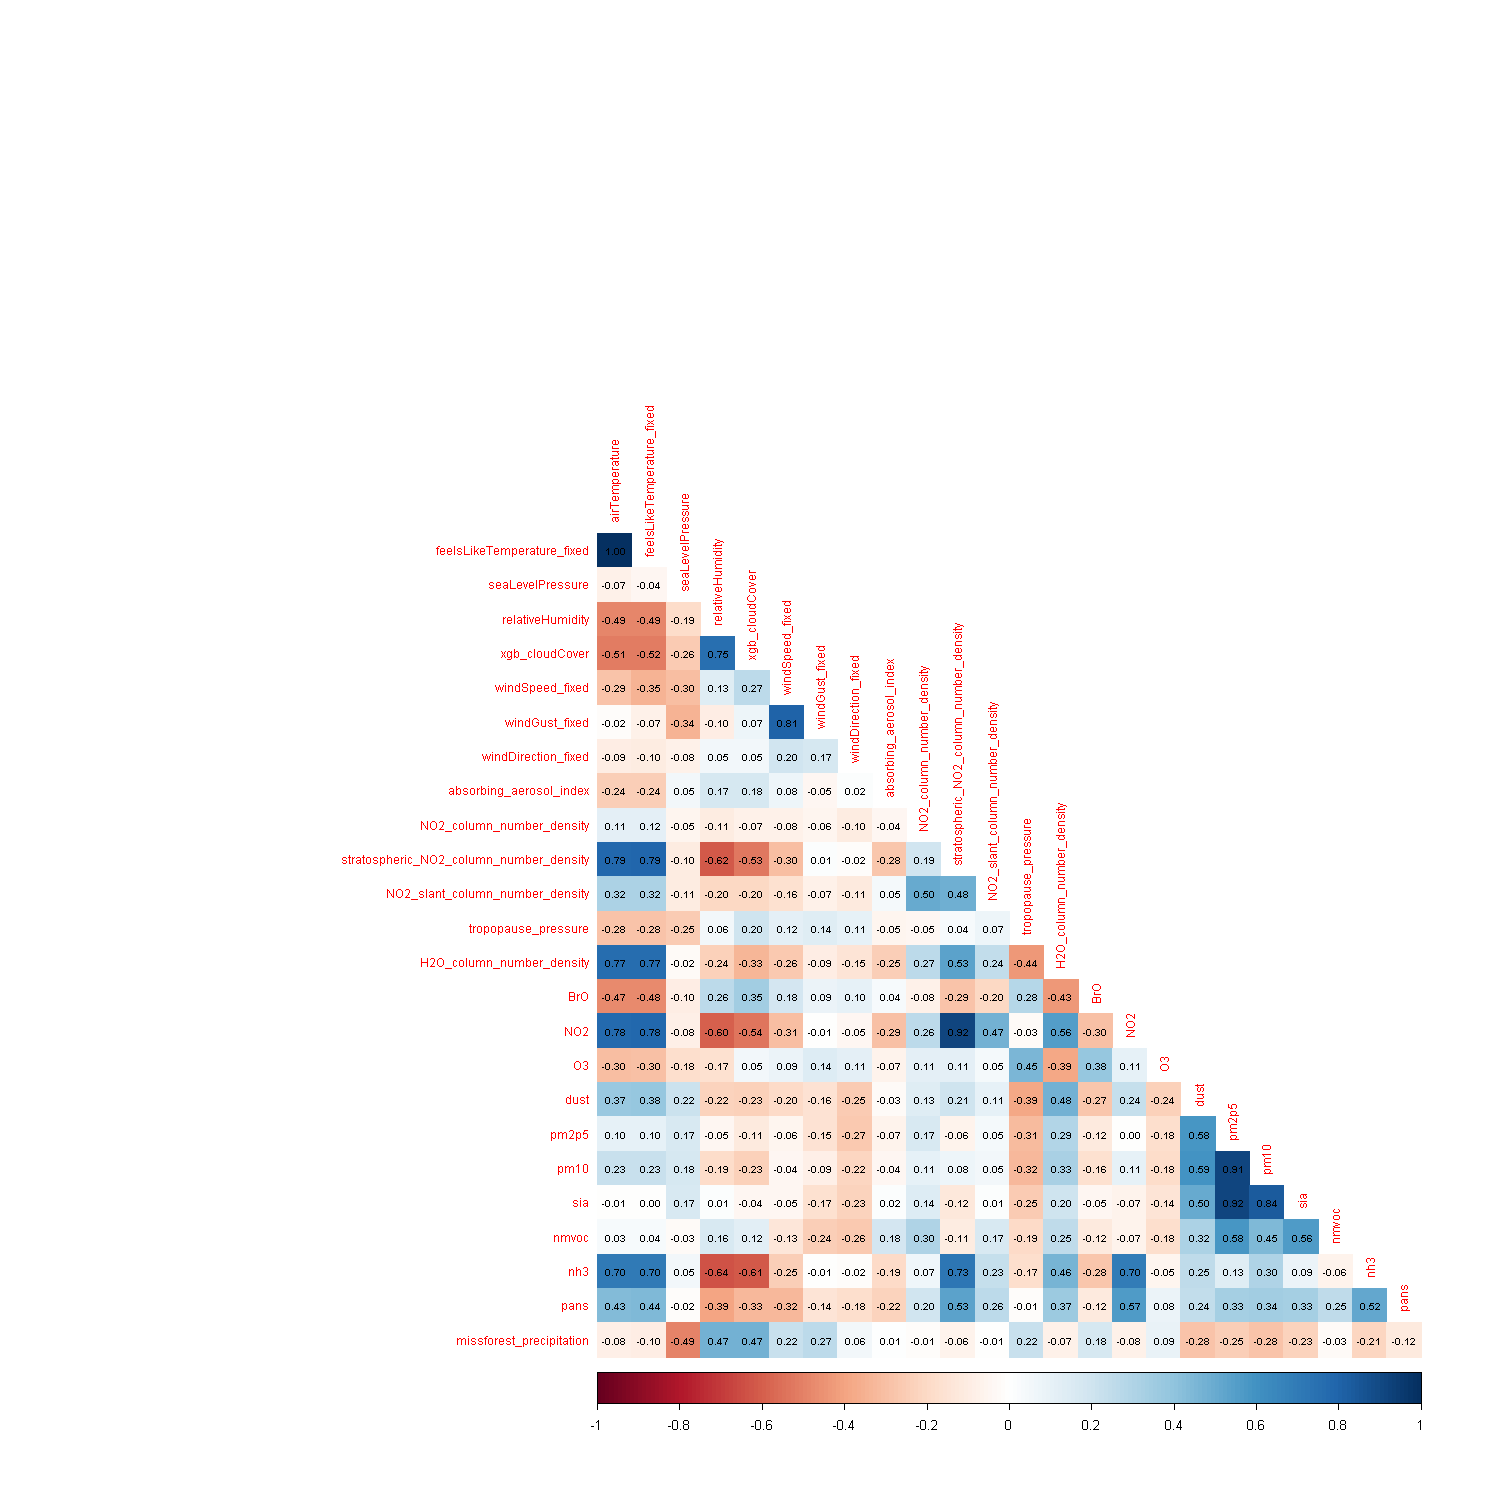

In [18]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

corrplot(corr, method = "color", type = "lower",addCoef.col = "black", number.cex = 0.6, tl.cex = 0.7, diag = FALSE)

In [ ]:
col_names_simple <- c(
  "airTemperature" = "Oro temperatūra",
  "feelsLikeTemperature_fixed" = "Juntamoji temp.",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Sant. oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2(Tr) VCD",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2(Go) VCD",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "pm2p5" = "PM2.5",
  "pm10" = "PM10",
  "sia" = "PM2.5 SIA",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pans" = "PAN",
  "tp" = "ECMWF krituliai",
  "t2m" = "ECMWF temperatūra",
  "missforest_precipitation" = "Krituliai"
)

labels_expr <- list(
  expression(Oro~temperatūra),
  expression(Juntamoji~temp.),
  expression(Slėgis~jūros~lygyje),
  expression(Sant.~oro~drėgnis),
  expression(Debesuotumas),
  expression(Vėjo~greitis),
  expression(Vėjo~gūsis),
  expression(Vėjo~kryptis),
  expression(AAI),
  expression(NO[2](Tr)~VCD),
  expression(Stratosferos~NO[2]~VCD),
  expression(NO[2]~SCD),
  expression(Tropopauzės~slėgis),
  expression(H[2]*O),
  expression(BrO~VCD),
  expression(NO[2](Go)~VCD),
  expression(O[3]~VCD),
  expression(Dulkės),
  expression(PM[2.5]),
  expression(PM[10]),
  expression(PM[2.5]~SIA),
  expression(NMVOC),
  expression(NH[3]),
  expression(PAN),
  expression(ECMWF~krituliai),
  expression(ECMWF~temperatūra),
  expression(Krituliai)
)

estimate <- corr
current_names <- rownames(estimate)
new_names <- ifelse(current_names %in% names(col_names_simple),
                    col_names_simple[current_names],
                    current_names)
rownames(estimate) <- new_names
colnames(estimate) <- new_names

expr_map <- setNames(labels_expr, names(col_names_simple))
tl_labels <- lapply(current_names, function(n) {
  if (n %in% names(expr_map)) expr_map[[n]] else as.expression(n)
})

n <- nrow(estimate)

options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

width_inch <- 17 / 2.54
height_inch <- width_inch * 1
png(filename = "corr_heatmap.png", width = width_inch, height = height_inch,
    units = "in", res = 300)

options(OutDec = ",")

corrplot(estimate,
         method = "color",
         type = "lower",
         addCoef.col = "black",
         number.cex = 0.5,
         tl.col = "white",
         tl.cex = 0.7,
         diag = FALSE,
         cl.pos = "b",
         cl.ratio = 0.1)

cl_ticks <- seq(-1, 1, by = 0.2)
axis(1,
     at = seq(0, 1, length.out = length(cl_ticks)),
     labels = gsub("\\.", ",", sprintf("%.1f", cl_ticks)),
     xpd = NA, cex.axis = 0.5, line = 1, lwd = 0, lwd.ticks = 0)

for (i in 2:n) {
  text(x = 0.3, y = n + 1 - i,
       labels = tl_labels[[i]],
       xpd = NA, adj = c(1, 0.5), cex = 0.6, col = "black")
}

for (j in 1:(n - 1)) {
  text(x = j, y = n - j + 0.8,
       labels = tl_labels[[j]],
       xpd = NA, adj = c(0, 0.5), cex = 0.6, col = "black",
       srt = 45)
}

options(OutDec = ".")
dev.off()

agg_record_1513439402 
                    2

### Koreliacija tarp kritulių ir visų kintamųjų

In [21]:
x <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-missforest_precipitation, -tp, -t2m, -tp_lag, -tp_error)

corr_missforest_precipitation <- cor(x, data_clean$missforest_precipitation, use = "complete.obs", method = "spearman") 
corr_missforest_precipitation

airTemperature,-0.083054679
feelsLikeTemperature_fixed,-0.099248052
seaLevelPressure,-0.494077132
relativeHumidity,0.473859312
xgb_cloudCover,0.474004229
windSpeed_fixed,0.220749460
windGust_fixed,0.267996484
windDirection_fixed,0.058109762
absorbing_aerosol_index,0.007253333
NO2_column_number_density,-0.010390022
stratospheric_NO2_column_number_density,-0.062281840


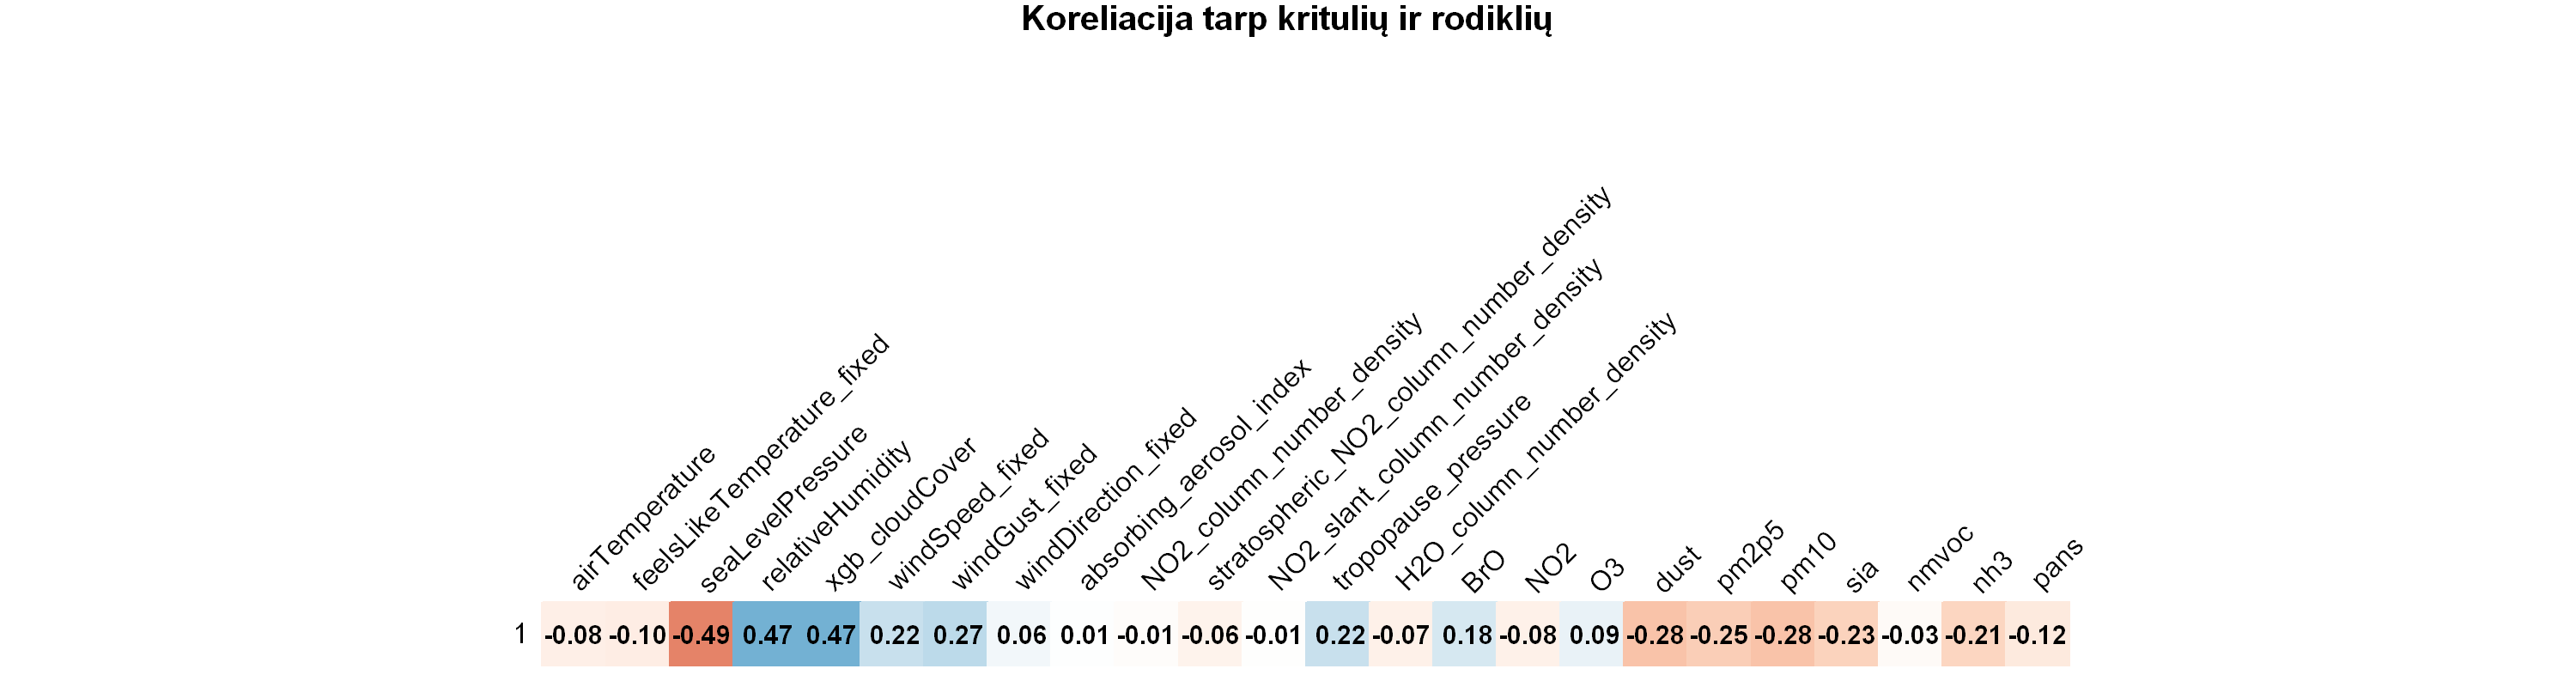

In [22]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)
corrplot(t(corr_missforest_precipitation), method = 'color', addCoef.col = "black", tl.srt = 45, number.cex = 0.9, tl.col = 'black', cl.pos = 'n', title = "Koreliacija tarp kritulių ir rodiklių", mar = c(0,0,1,0))

In [23]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

width_inch = 14 / 2.54
height_inch = width_inch * 0.55

rownames(corr_missforest_precipitation) <- col_names

part1 <- as.matrix(corr_missforest_precipitation[1:8, , drop = FALSE])
part2 <- as.matrix(corr_missforest_precipitation[9:16, , drop = FALSE])
part3 <- as.matrix(corr_missforest_precipitation[17:24, , drop = FALSE])

colnames(part1) <- "Krituliai"; colnames(part2) <- "Krituliai"; colnames(part3) <- "Krituliai"

png(filename = "corr_heatmap_2.png", width = width_inch, height = height_inch, units = "in", res = 300)
layout(matrix(c(1, 2, 3), 1, 3))
par(mfrow = c(1, 3), oma = c(0, 0, 4, 0))

options(OutDec = ",")

corrplot(part1, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part2, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part3, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=0.8, tl.cex = 0.8, tl.offset = 1)

mtext("Koreliacija tarp kritulių ir kitų rodiklių", side = 3, line = 2, outer = TRUE, cex = 0.85, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_1737164900 
                    2

In [24]:
col_names_simple <- c(
  "airTemperature" = "Oro temperatūra",
  "feelsLikeTemperature_fixed" = "Juntamoji temp.",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Sant. oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2(Tr) VCD",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2(Go) VCD",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "pm2p5" = "PM2.5",
  "pm10" = "PM10",
  "sia" = "PM2.5 SIA",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pans" = "PAN"
)

labels_expr <- list(
  expression(Oro~temperatūra),
  expression(Juntamoji~temp.),
  expression(Slėgis~jūros~lygyje),
  expression(Sant.~oro~drėgnis),
  expression(Debesuotumas),
  expression(Vėjo~greitis),
  expression(Vėjo~gūsis),
  expression(Vėjo~kryptis),
  expression(AAI),
  expression(NO[2](Tr)~VCD),
  expression(Stratosferos~NO[2]~VCD),
  expression(NO[2]~SCD),
  expression(Tropopauzės~slėgis),
  expression(H[2]*O),
  expression(BrO~VCD),
  expression(NO[2](Go)~VCD),
  expression(O[3]~VCD),
  expression(Dulkės),
  expression(PM[2.5]),
  expression(PM[10]),
  expression(PM[2.5]~SIA),
  expression(NMVOC),
  expression(NH[3]),
  expression(PAN)
)


In [25]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

add_row_labels <- function(labels, n = 8, cex = 0.82) {
  usr <- par("usr")
  x <- usr[1]
  for (i in 1:n) {
    y <- n + 1 - i
    text(x = x, y = y, labels = labels[[i]],
         xpd = NA, adj = c(1, 0.5), cex = cex, col = "black")
  }
}

add_col_headers <- function() {
  text(x = 1, y = par("usr")[4] + 0.1, labels = "Krituliai",
       xpd = NA, adj = c(0.5, 0), cex = 0.72, col = "black")
}

rownames(corr_missforest_precipitation) <- unname(col_names_simple)

part1 <- as.matrix(corr_missforest_precipitation[1:8,   , drop = FALSE])
part2 <- as.matrix(corr_missforest_precipitation[9:16,  , drop = FALSE])
part3 <- as.matrix(corr_missforest_precipitation[17:24, , drop = FALSE])

colnames(part1) <- "Krituliai"
colnames(part2) <- "Krituliai"
colnames(part3) <- "Krituliai"

width_inch <- 14 / 2.54
height_inch <- width_inch * 0.55

png(filename = "corr_heatmap_2.png", width = width_inch, height = height_inch,
    units = "in", res = 300)

par(mfrow = c(1, 3),
    mar = c(2, 9, 3, 1),
    oma = c(0, 0, 2, 0))

options(OutDec = ",")

corrplot(part1, method = 'color', addCoef.col = "black", tl.col = 'black',
         tl.srt = 0, tl.pos = 'n', cl.pos = 'n',
         number.cex = 0.85, tl.cex = 0.85, mar = c(2, 10, 3, 1))
add_row_labels(labels_expr[1:8])
add_col_headers()

corrplot(part2, method = 'color', addCoef.col = "black", tl.col = 'black',
         tl.srt = 0, tl.pos = 'n', cl.pos = 'n',
         number.cex = 0.85, tl.cex = 0.85, mar = c(2, 10, 3, 1))
add_row_labels(labels_expr[9:16])
add_col_headers()

corrplot(part3, method = 'color', addCoef.col = "black", tl.col = 'black',
         tl.srt = 0, tl.pos = 'n', cl.pos = 'n',
         number.cex = 0.85, tl.cex = 0.85, mar = c(2, 10, 3, 1))
add_row_labels(labels_expr[17:24])
add_col_headers()

mtext("Koreliacija tarp kritulių ir kitų rodiklių",
      side = 3, line = -0.5, outer = TRUE, cex = 0.75, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_1248053192 
                    2

### Dalinės koreliacijos

In [26]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

In [27]:
all_variables_pcor <- pcor(numeric_columns, method = 'spearman')
all_variables_pcor

,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,NO2_column_number_density,⋯,NO2,O3,dust,pm2p5,pm10,sia,nmvoc,nh3,pans,missforest_precipitation
airTemperature,1.000000000,0.983354091,-0.100561715,-0.0293317334,-0.01829107,0.4450828782,-0.050902303,-0.0214701192,-0.013532133,-0.049024077,⋯,-0.0147016185,-0.003823001,-0.02568540,0.0251931743,0.081289368,-0.138325739,0.0026860191,0.064316612,0.022534555,0.048509904
feelsLikeTemperature_fixed,0.983354091,1.000000000,0.069288312,0.0170815438,0.01915846,-0.4620415442,0.058582653,0.0180500919,0.017935213,0.023154788,⋯,0.0533657308,-0.067359244,0.03840306,-0.0137253978,-0.067698871,0.102866831,0.0039515599,-0.028635552,-0.034312460,-0.039213315
seaLevelPressure,-0.100561715,0.069288312,1.000000000,-0.1027887560,-0.04095634,-0.1067086672,-0.043976176,-0.0032367044,0.032425299,0.019690132,⋯,0.0078245628,-0.170668802,0.08464774,0.0191686403,0.025726741,-0.008819260,-0.1307036247,0.015037214,-0.050815910,-0.230009639
relativeHumidity,-0.029331733,0.017081544,-0.102788756,1.0000000000,0.45319307,-0.0248200143,-0.170100912,0.1134837816,-0.036952174,-0.116555907,⋯,0.0004122043,-0.215936114,-0.07755395,0.0049621359,-0.027190458,0.069576996,-0.0006090082,-0.139700966,-0.099917429,0.382006746
xgb_cloudCover,-0.018291065,0.019158462,-0.040956339,0.4531930671,1.00000000,0.1061364307,-0.021793392,-0.0234001894,0.031674728,0.034357196,⋯,-0.0957300432,0.075803347,0.10376015,-0.0396322909,-0.019565723,0.016634799,0.0965554380,-0.139558747,0.065635579,0.143175841
windSpeed_fixed,0.445082878,-0.462041544,-0.106708667,-0.0248200143,0.10613643,1.0000000000,0.737983077,0.1053868078,0.037415084,0.033764436,⋯,0.0074624848,-0.090272606,-0.02941813,0.0099620190,0.027694510,0.062289332,-0.0083892702,-0.022585762,-0.137106440,-0.100764245
windGust_fixed,-0.050902303,0.058582653,-0.043976176,-0.1701009119,-0.02179339,0.7379830773,1.000000000,-0.0210474177,-0.030662132,-0.016932449,⋯,0.0048921519,0.040221873,0.01712775,-0.0090699047,0.001063330,-0.031868709,-0.0905188001,-0.004345376,0.039656645,0.228897856
windDirection_fixed,-0.021470119,0.018050092,-0.003236704,0.1134837816,-0.02340019,0.1053868078,-0.021047418,1.0000000000,0.022845302,0.015926135,⋯,0.0094034222,0.049182778,-0.09940986,-0.0805235902,0.032772442,0.043027093,-0.0699394921,0.062948500,-0.073902996,-0.079629774
absorbing_aerosol_index,-0.013532133,0.017935213,0.032425299,-0.0369521737,0.03167473,0.0374150838,-0.030662132,0.0228453018,1.000000000,-0.077981510,⋯,-0.0543698976,-0.009950654,0.11194093,-0.2934614279,0.150546083,0.143225418,0.2901040898,0.038914741,-0.078402538,0.018562744
NO2_column_number_density,-0.049024077,0.023154788,0.019690132,-0.1165559066,0.03435720,0.0337644358,-0.016932449,0.0159261352,-0.077981510,1.000000000,⋯,0.1499171858,0.133091240,-0.01958220,-0.0093834041,-0.024534386,0.013153205,0.1882171186,-0.004695841,-0.028436519,0.037023965


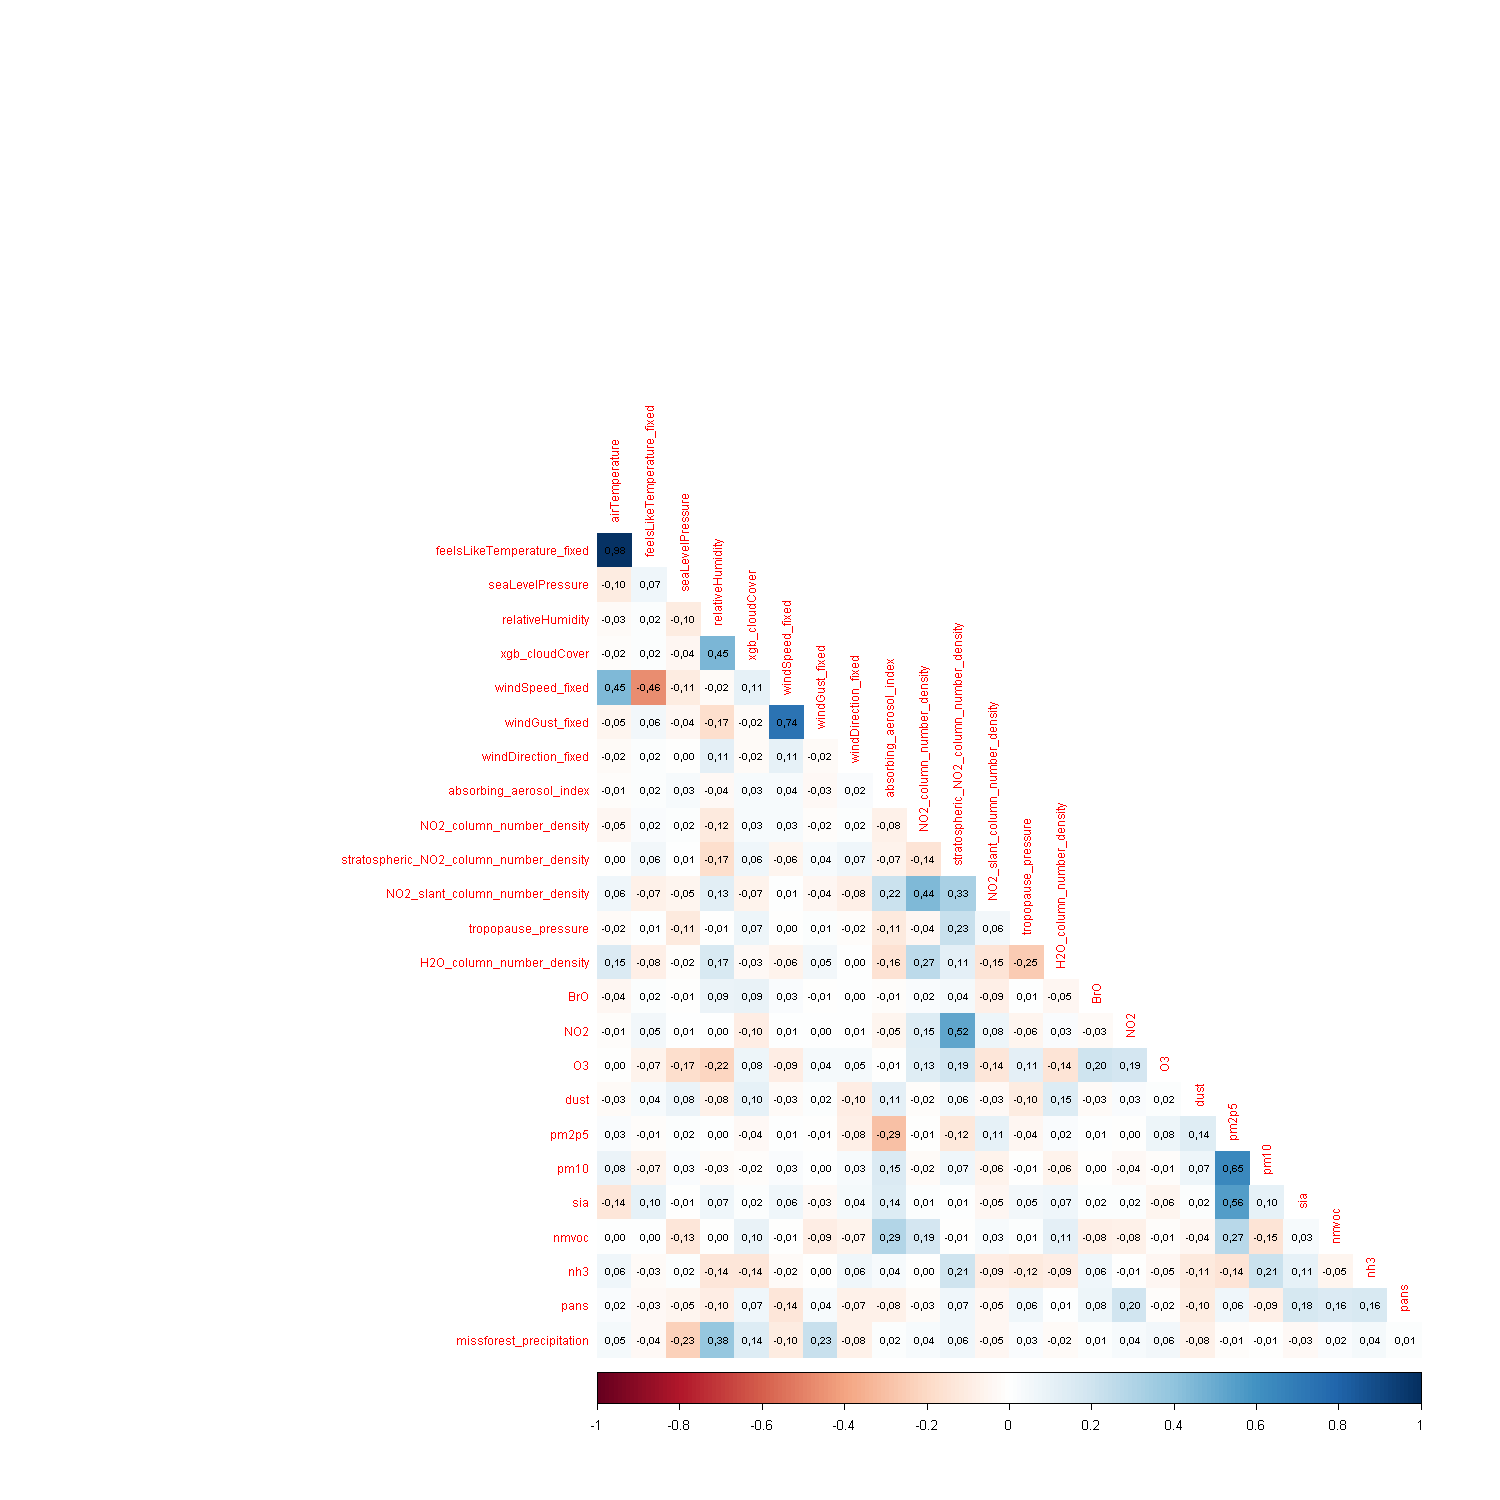

In [28]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

options(OutDec = ",")
corrplot(all_variables_pcor$estimate, method = "color", type = "lower", addCoef.col = "black", number.cex = 0.6, tl.cex = 0.7, diag = FALSE)
options(OutDec = ".")

In [ ]:
col_names_simple <- c(
  "airTemperature" = "Oro temperatūra",
  "feelsLikeTemperature_fixed" = "Juntamoji temp.",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Sant. oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2(Tr) VCD",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2(Go) VCD",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "pm2p5" = "PM2.5",
  "pm10" = "PM10",
  "sia" = "PM2.5 SIA",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pans" = "PAN",
  "tp" = "ECMWF krituliai",
  "t2m" = "ECMWF temperatūra",
  "missforest_precipitation" = "Krituliai"
)

labels_expr <- list(
  expression(Oro~temperatūra),
  expression(Juntamoji~temp.),
  expression(Slėgis~jūros~lygyje),
  expression(Sant.~oro~drėgnis),
  expression(Debesuotumas),
  expression(Vėjo~greitis),
  expression(Vėjo~gūsis),
  expression(Vėjo~kryptis),
  expression(AAI),
  expression(NO[2](Tr)~VCD),
  expression(Stratosferos~NO[2]~VCD),
  expression(NO[2]~SCD),
  expression(Tropopauzės~slėgis),
  expression(H[2]*O),
  expression(BrO~VCD),
  expression(NO[2](Go)~VCD),
  expression(O[3]~VCD),
  expression(Dulkės),
  expression(PM[2.5]),
  expression(PM[10]),
  expression(PM[2.5]~SIA),
  expression(NMVOC),
  expression(NH[3]),
  expression(PAN),
  expression(ECMWF~krituliai),
  expression(ECMWF~temperatūra),
  expression(Krituliai)
)

In [30]:
col_names_simple <- c(
  "airTemperature" = "Oro temperatūra",
  "feelsLikeTemperature_fixed" = "Juntamoji temp.",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Sant. oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2(Tr) VCD",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2(Go) VCD",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "pm2p5" = "PM2.5",
  "pm10" = "PM10",
  "sia" = "PM2.5 SIA",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pans" = "PAN",
  "tp" = "ECMWF krituliai",
  "t2m" = "ECMWF temperatūra",
  "missforest_precipitation" = "Krituliai"
)

labels_expr <- list(
  expression(Oro~temperatūra),
  expression(Juntamoji~temp.),
  expression(Slėgis~jūros~lygyje),
  expression(Sant.~oro~drėgnis),
  expression(Debesuotumas),
  expression(Vėjo~greitis),
  expression(Vėjo~gūsis),
  expression(Vėjo~kryptis),
  expression(AAI),
  expression(NO[2](Tr)~VCD),
  expression(Stratosferos~NO[2]~VCD),
  expression(NO[2]~SCD),
  expression(Tropopauzės~slėgis),
  expression(H[2]*O),
  expression(BrO~VCD),
  expression(NO[2](Go)~VCD),
  expression(O[3]~VCD),
  expression(Dulkės),
  expression(PM[2.5]),
  expression(PM[10]),
  expression(PM[2.5]~SIA),
  expression(NMVOC),
  expression(NH[3]),
  expression(PAN),
  expression(ECMWF~krituliai),
  expression(ECMWF~temperatūra),
  expression(Krituliai)
)

In [31]:
estimate <- all_variables_pcor$estimate
current_names <- rownames(estimate)
new_names <- ifelse(current_names %in% names(col_names_simple),
                    col_names_simple[current_names],
                    current_names)
rownames(estimate) <- new_names
colnames(estimate) <- new_names

expr_map <- setNames(labels_expr, names(col_names_simple))
tl_labels <- lapply(current_names, function(n) {
  if (n %in% names(expr_map)) expr_map[[n]] else as.expression(n)
})

n <- nrow(estimate)

width_inch <- 17 / 2.54
height_inch <- width_inch * 1

png(filename = "pcor_heatmap.png", width = width_inch, height = height_inch,
    units = "in", res = 300)

options(OutDec = ",")

corrplot(estimate,
         method = "color",
         type = "lower",
         addCoef.col = "black",
         number.cex = 0.5,
         tl.col = "white",
         tl.cex = 0.7,
         diag = FALSE,
         cl.pos = "b",
         cl.ratio = 0.1,
         cl.cex = 0.6)

for (i in 2:n) {
  text(x = 0.3, y = n + 1 - i,
       labels = tl_labels[[i]],
       xpd = NA, adj = c(1, 0.5), cex = 0.6, col = "black")
}

for (j in 1:(n - 1)) {
  text(x = j, y = n - j + 0.8,
       labels = tl_labels[[j]],
       xpd = NA, adj = c(0, 0.5), cex = 0.6, col = "black",
       srt = 45)
}

options(OutDec = ".")
dev.off()

agg_record_85918132 
                  2

### Kryžminė koreliacija

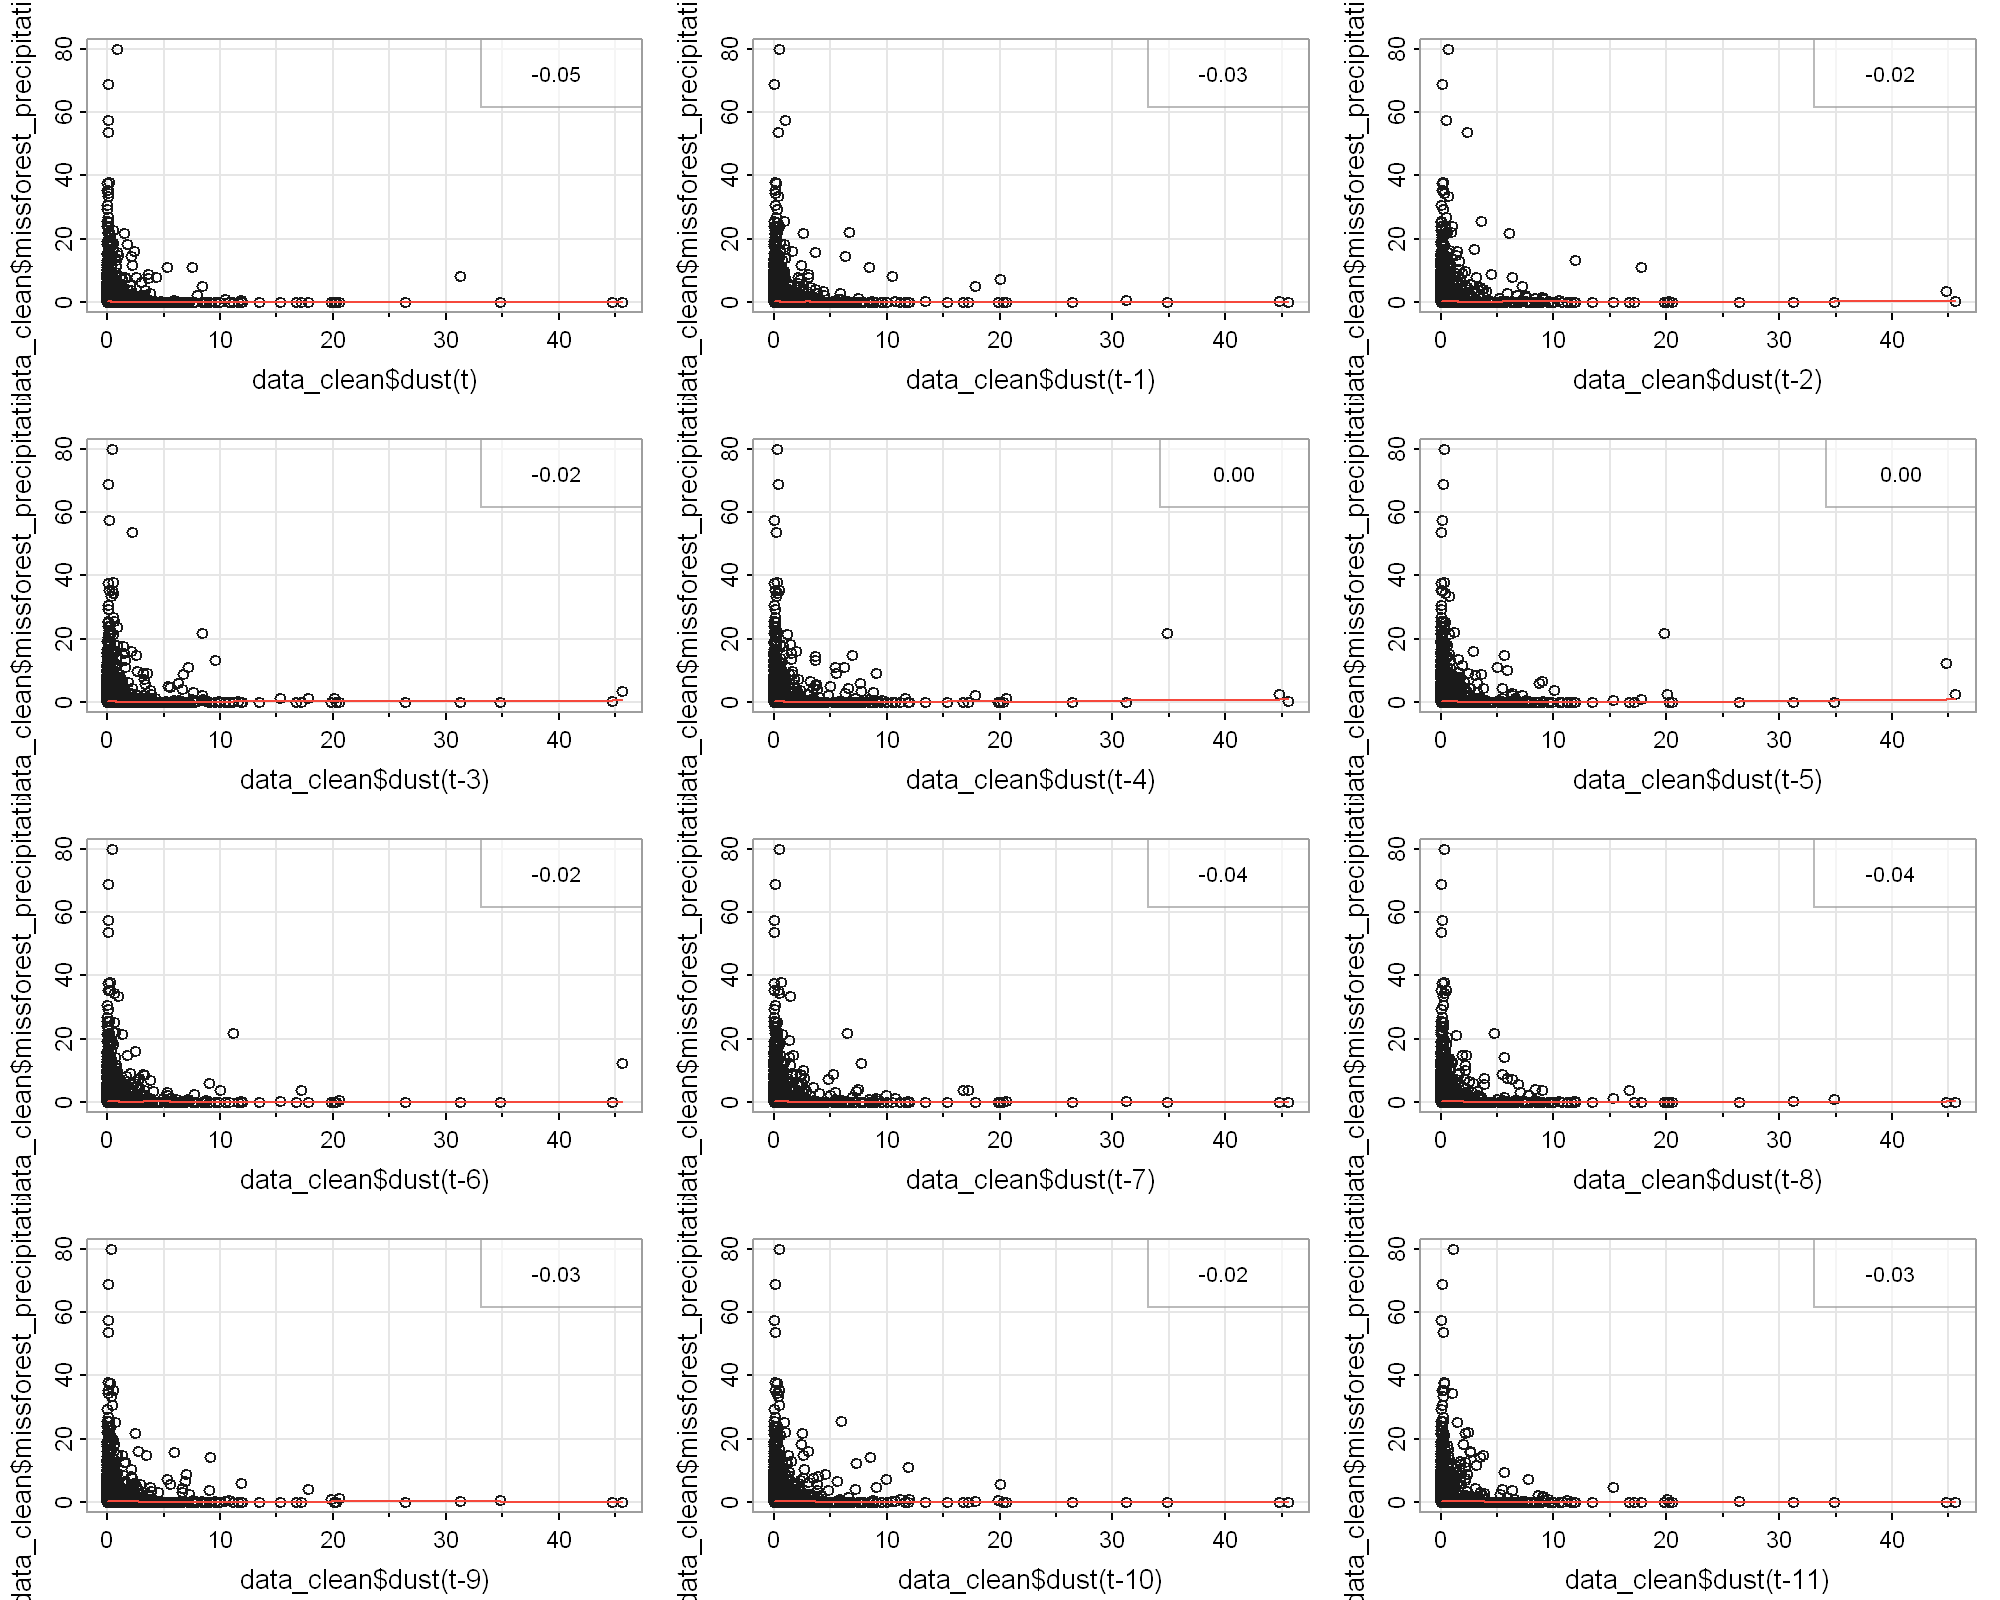

In [32]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 200)

astsa::lag2.plot(data_clean$dust, data_clean$missforest_precipitation, 11)

In [33]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

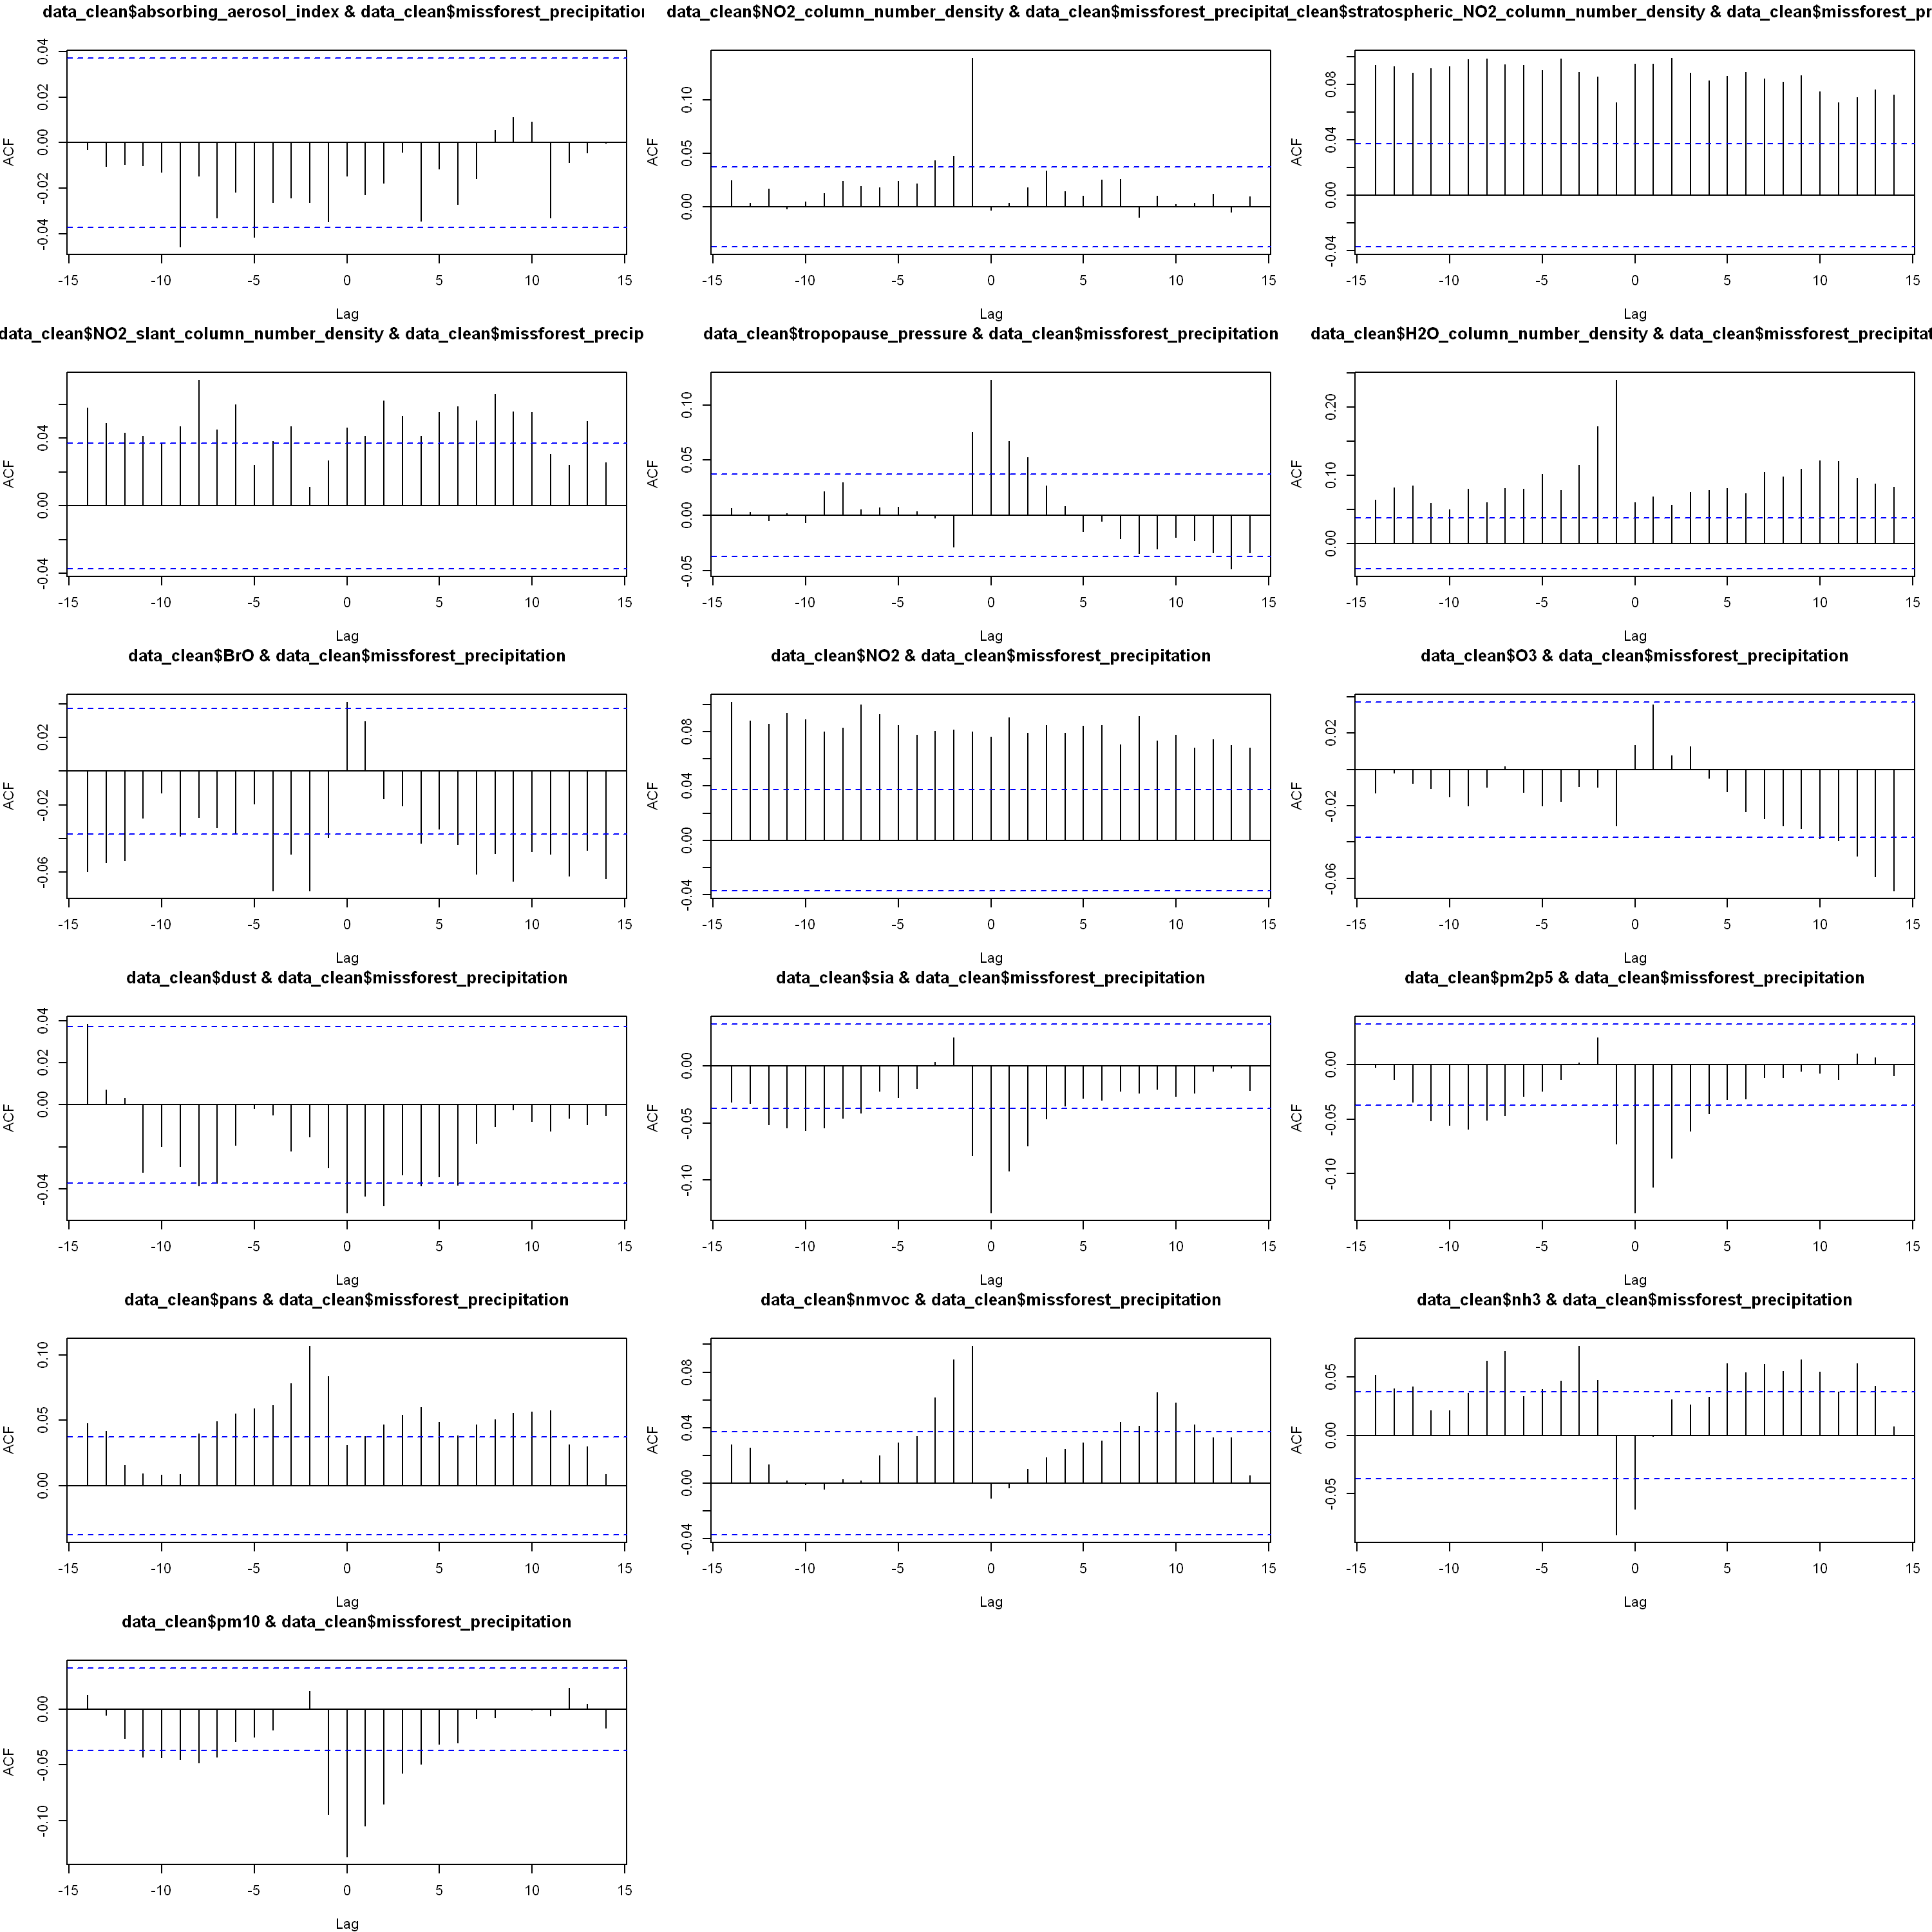

In [34]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 200)
par(mfrow = c(6, 3), mar = c(4, 4, 3, 1))

ccf(data_clean$absorbing_aerosol_index, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$stratospheric_NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$NO2_slant_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$tropopause_pressure, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$BrO, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$NO2, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$O3, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$dust, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$sia, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$pm2p5, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$pans, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$nmvoc, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$nh3, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$pm10, data_clean$missforest_precipitation, lag.max = 14)

par(mfrow = c(1, 1))


Autocorrelations of series 'X', by lag

   -14    -13    -12    -11    -10     -9     -8     -7     -6     -5     -4 
 0.028  0.026  0.014  0.002 -0.001 -0.004  0.003  0.002  0.020  0.029  0.034 
    -3     -2     -1      0      1      2      3      4      5      6      7 
 0.062  0.089  0.099 -0.011 -0.003  0.010  0.019  0.025  0.029  0.031  0.044 
     8      9     10     11     12     13     14 
 0.041  0.065  0.058  0.042  0.033  0.033  0.006 


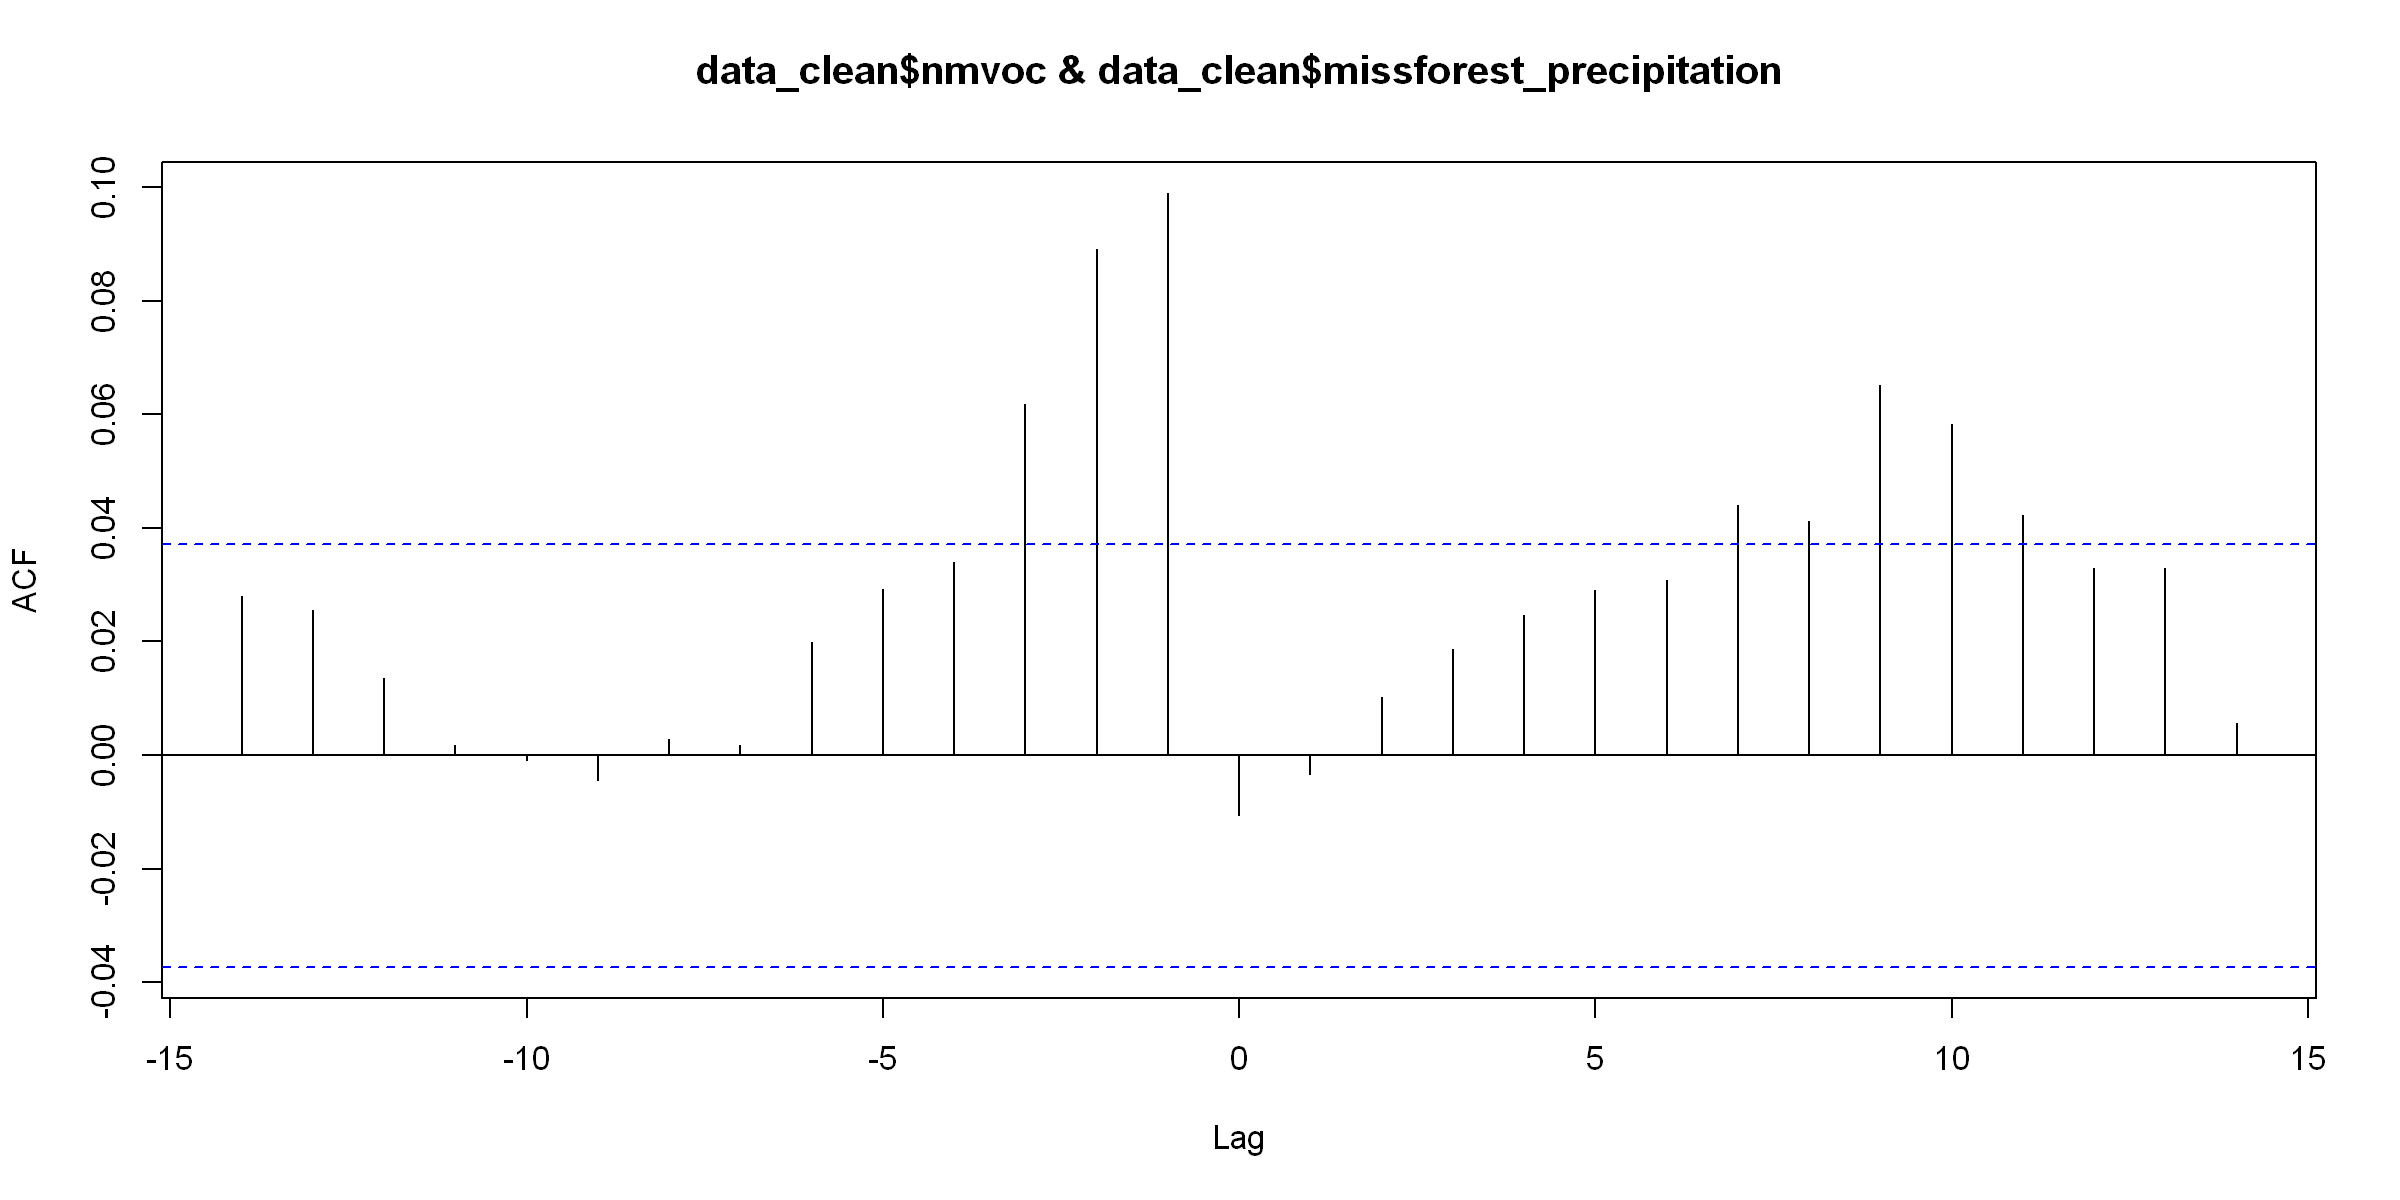

In [35]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
print(ccf(data_clean$nmvoc, data_clean$missforest_precipitation, lag.max = 14))

   Lag          r_P     lower_P    upper_P           r_S     lower_S    upper_S
1  -14 -0.002223983 -0.03941175 0.03941175 -0.0336392349 -0.04525274 0.04525274
2  -13 -0.013868822 -0.03974539 0.03974539 -0.0207015234 -0.04518418 0.04518418
3  -12 -0.034467757 -0.03919679 0.03919679 -0.0385410063 -0.04505677 0.04505677
4  -11 -0.051248153 -0.03882697 0.03882697 -0.0558670011 -0.04477602 0.04477602
5  -10 -0.055636849 -0.04015980 0.04015980 -0.0510826140 -0.04596125 0.04596125
6   -9 -0.059292630 -0.04313389 0.04313389 -0.0327162138 -0.04653044 0.04653044
7   -8 -0.050922925 -0.04073339 0.04073339 -0.0334923327 -0.04587558 0.04587558
8   -7 -0.046987607 -0.03917108 0.03917108 -0.0405627213 -0.04535950 0.04535950
9   -6 -0.029273351 -0.03940601 0.03940601 -0.0318777548 -0.04410975 0.04410975
10  -5 -0.024539150 -0.03818874 0.03818874 -0.0403513231 -0.04325948 0.04325948
11  -4 -0.013691316 -0.03900416 0.03900416 -0.0379869613 -0.04231644 0.04231644
12  -3  0.001763496 -0.03992483 0.039924

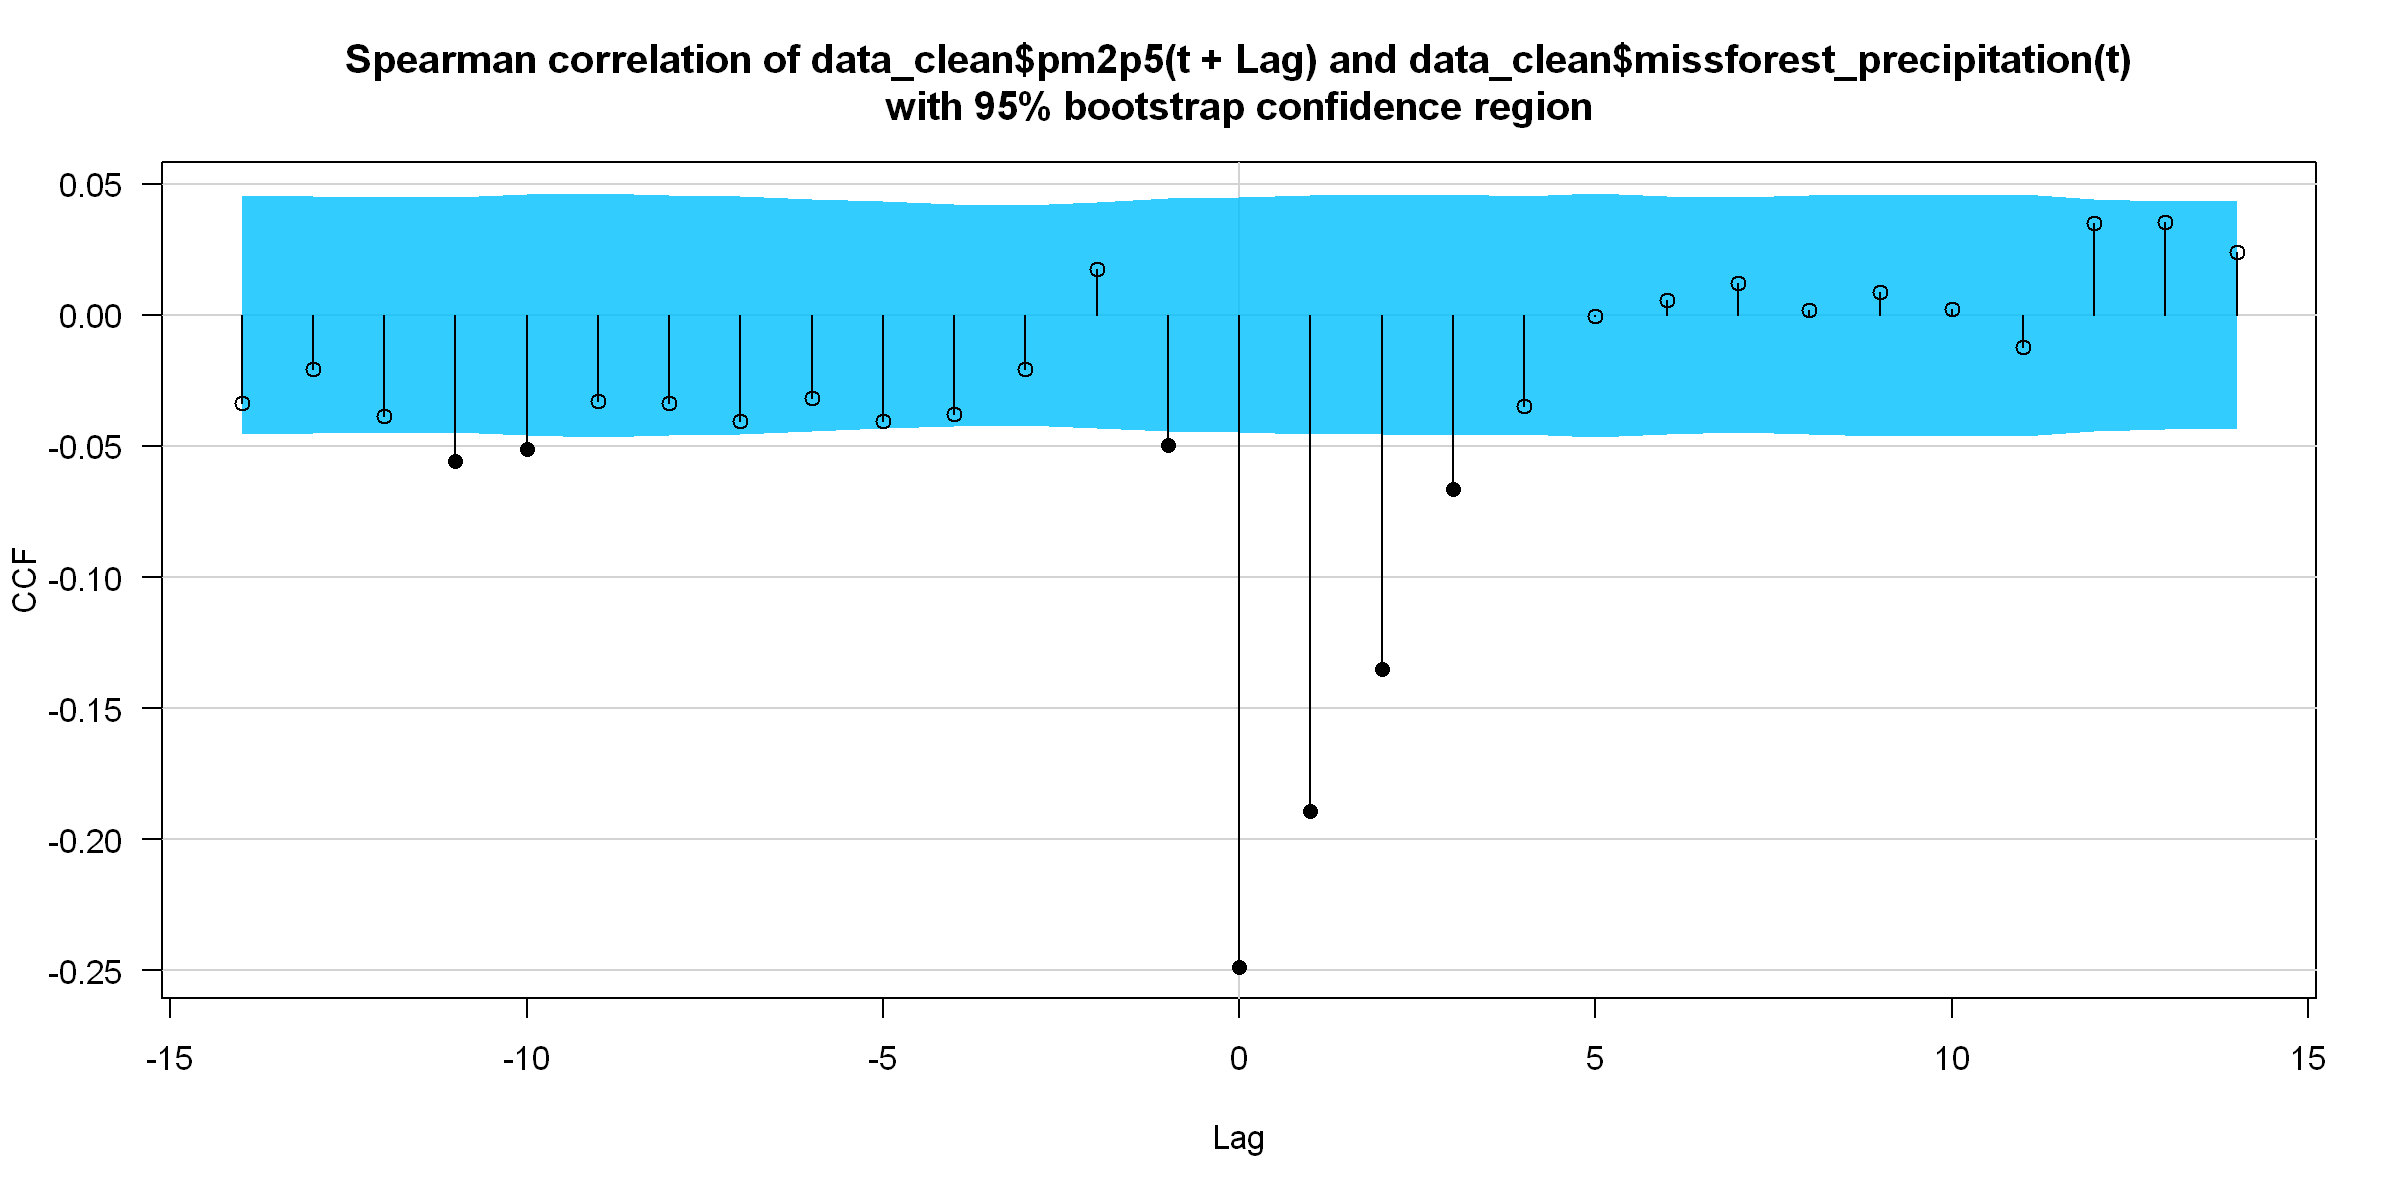

In [36]:
print(ccf_boot(data_clean$pm2p5, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman"))


In [38]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

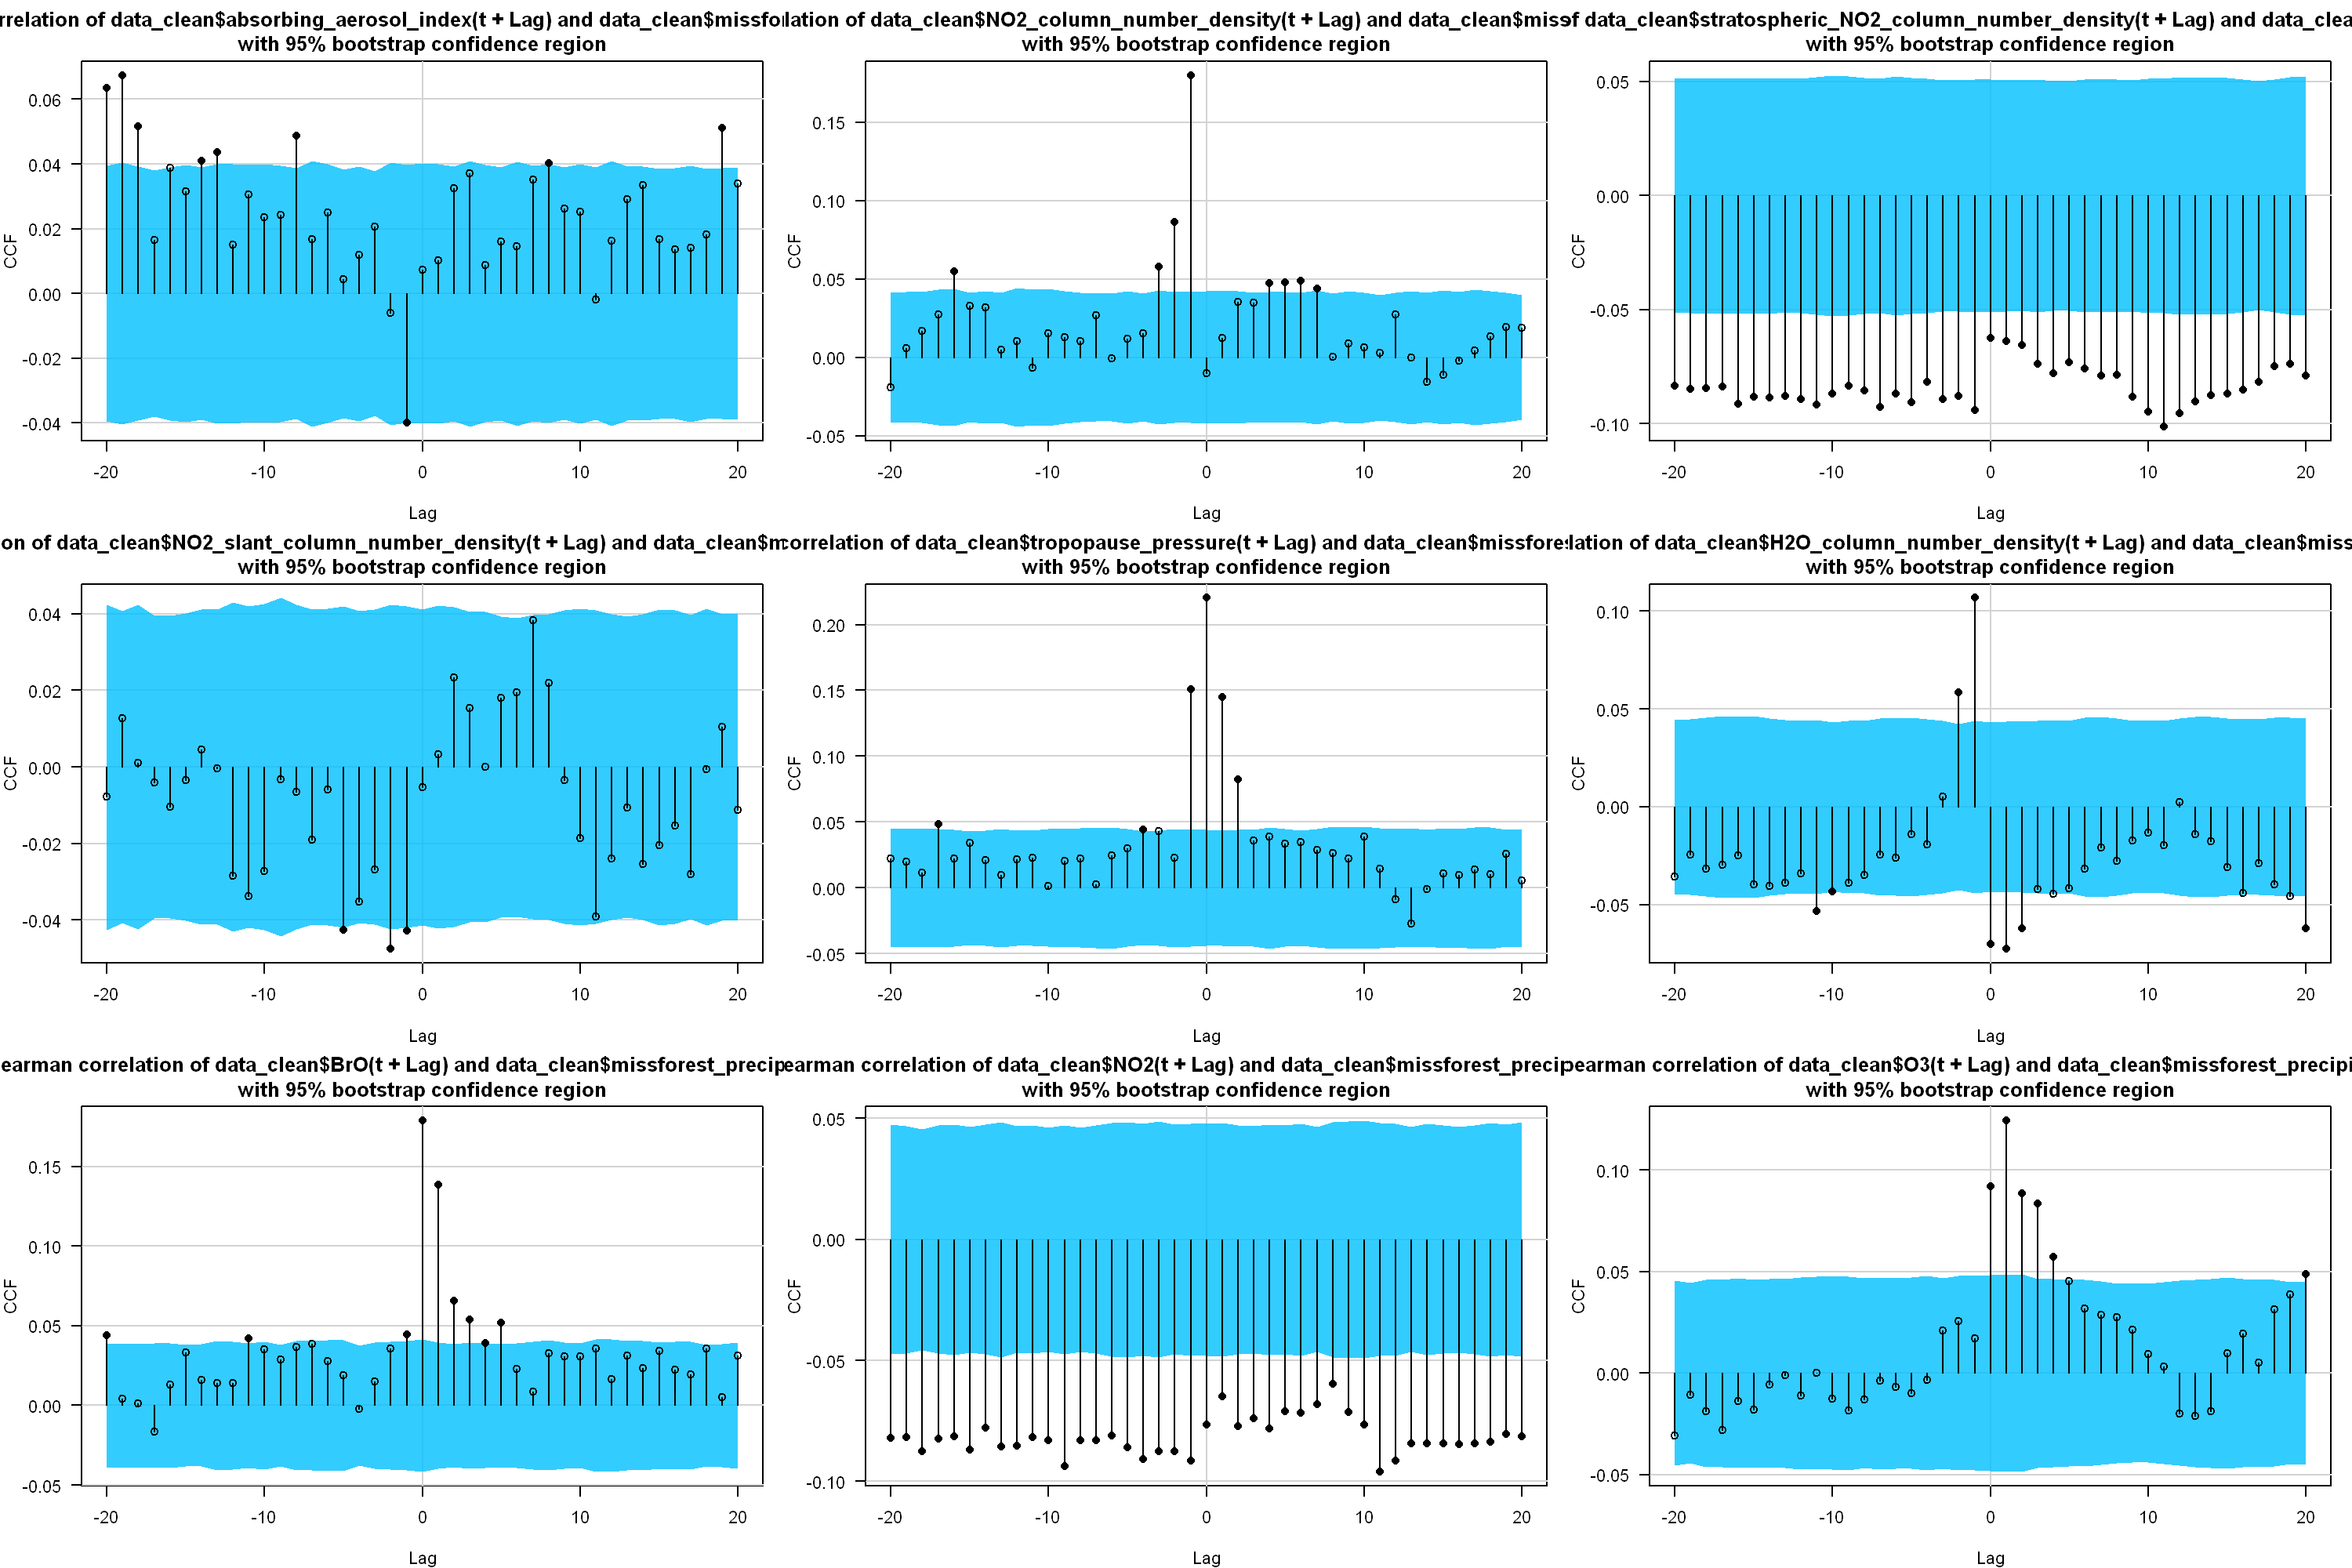

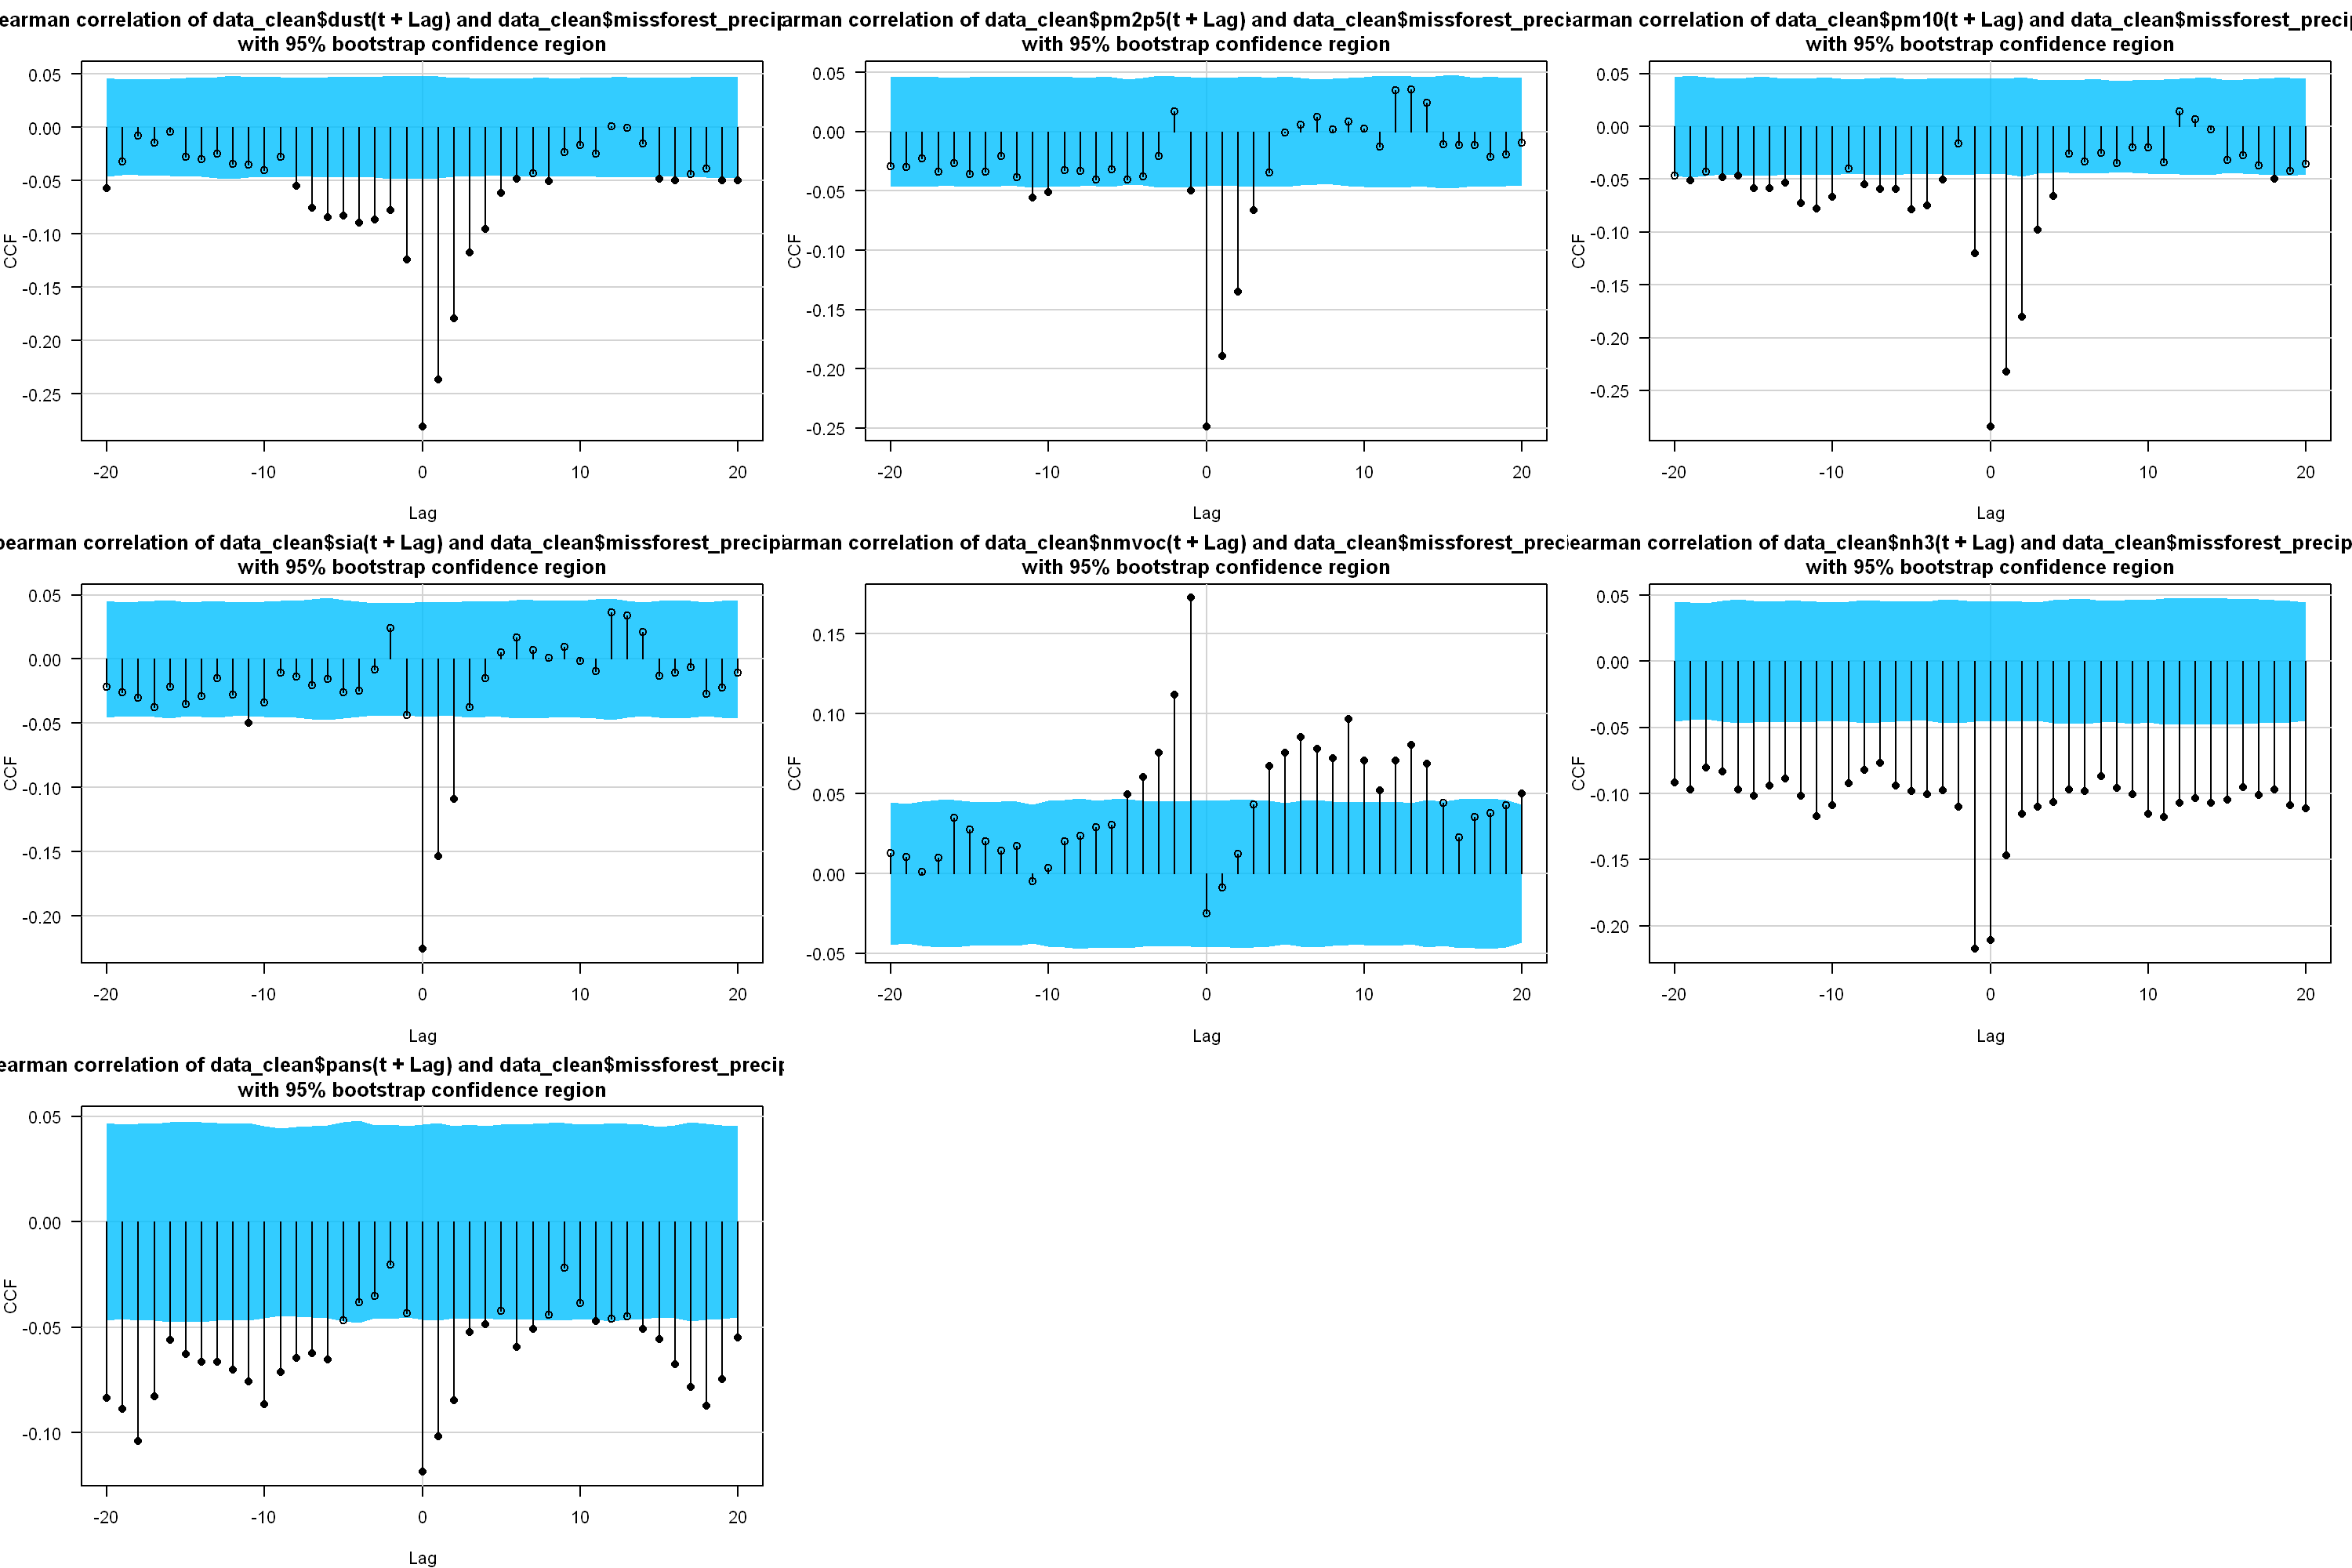

In [39]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 200)
par(mfrow = c(3, 3), mar = c(4, 4, 3, 1))

ccf_boot(data_clean$absorbing_aerosol_index, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$stratospheric_NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$NO2_slant_column_number_density, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$tropopause_pressure, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$BrO, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$NO2, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$O3, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$dust, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$pm2p5, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$pm10, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$sia, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$nmvoc, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$nh3, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$pans, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")

par(mfrow = c(1, 1))

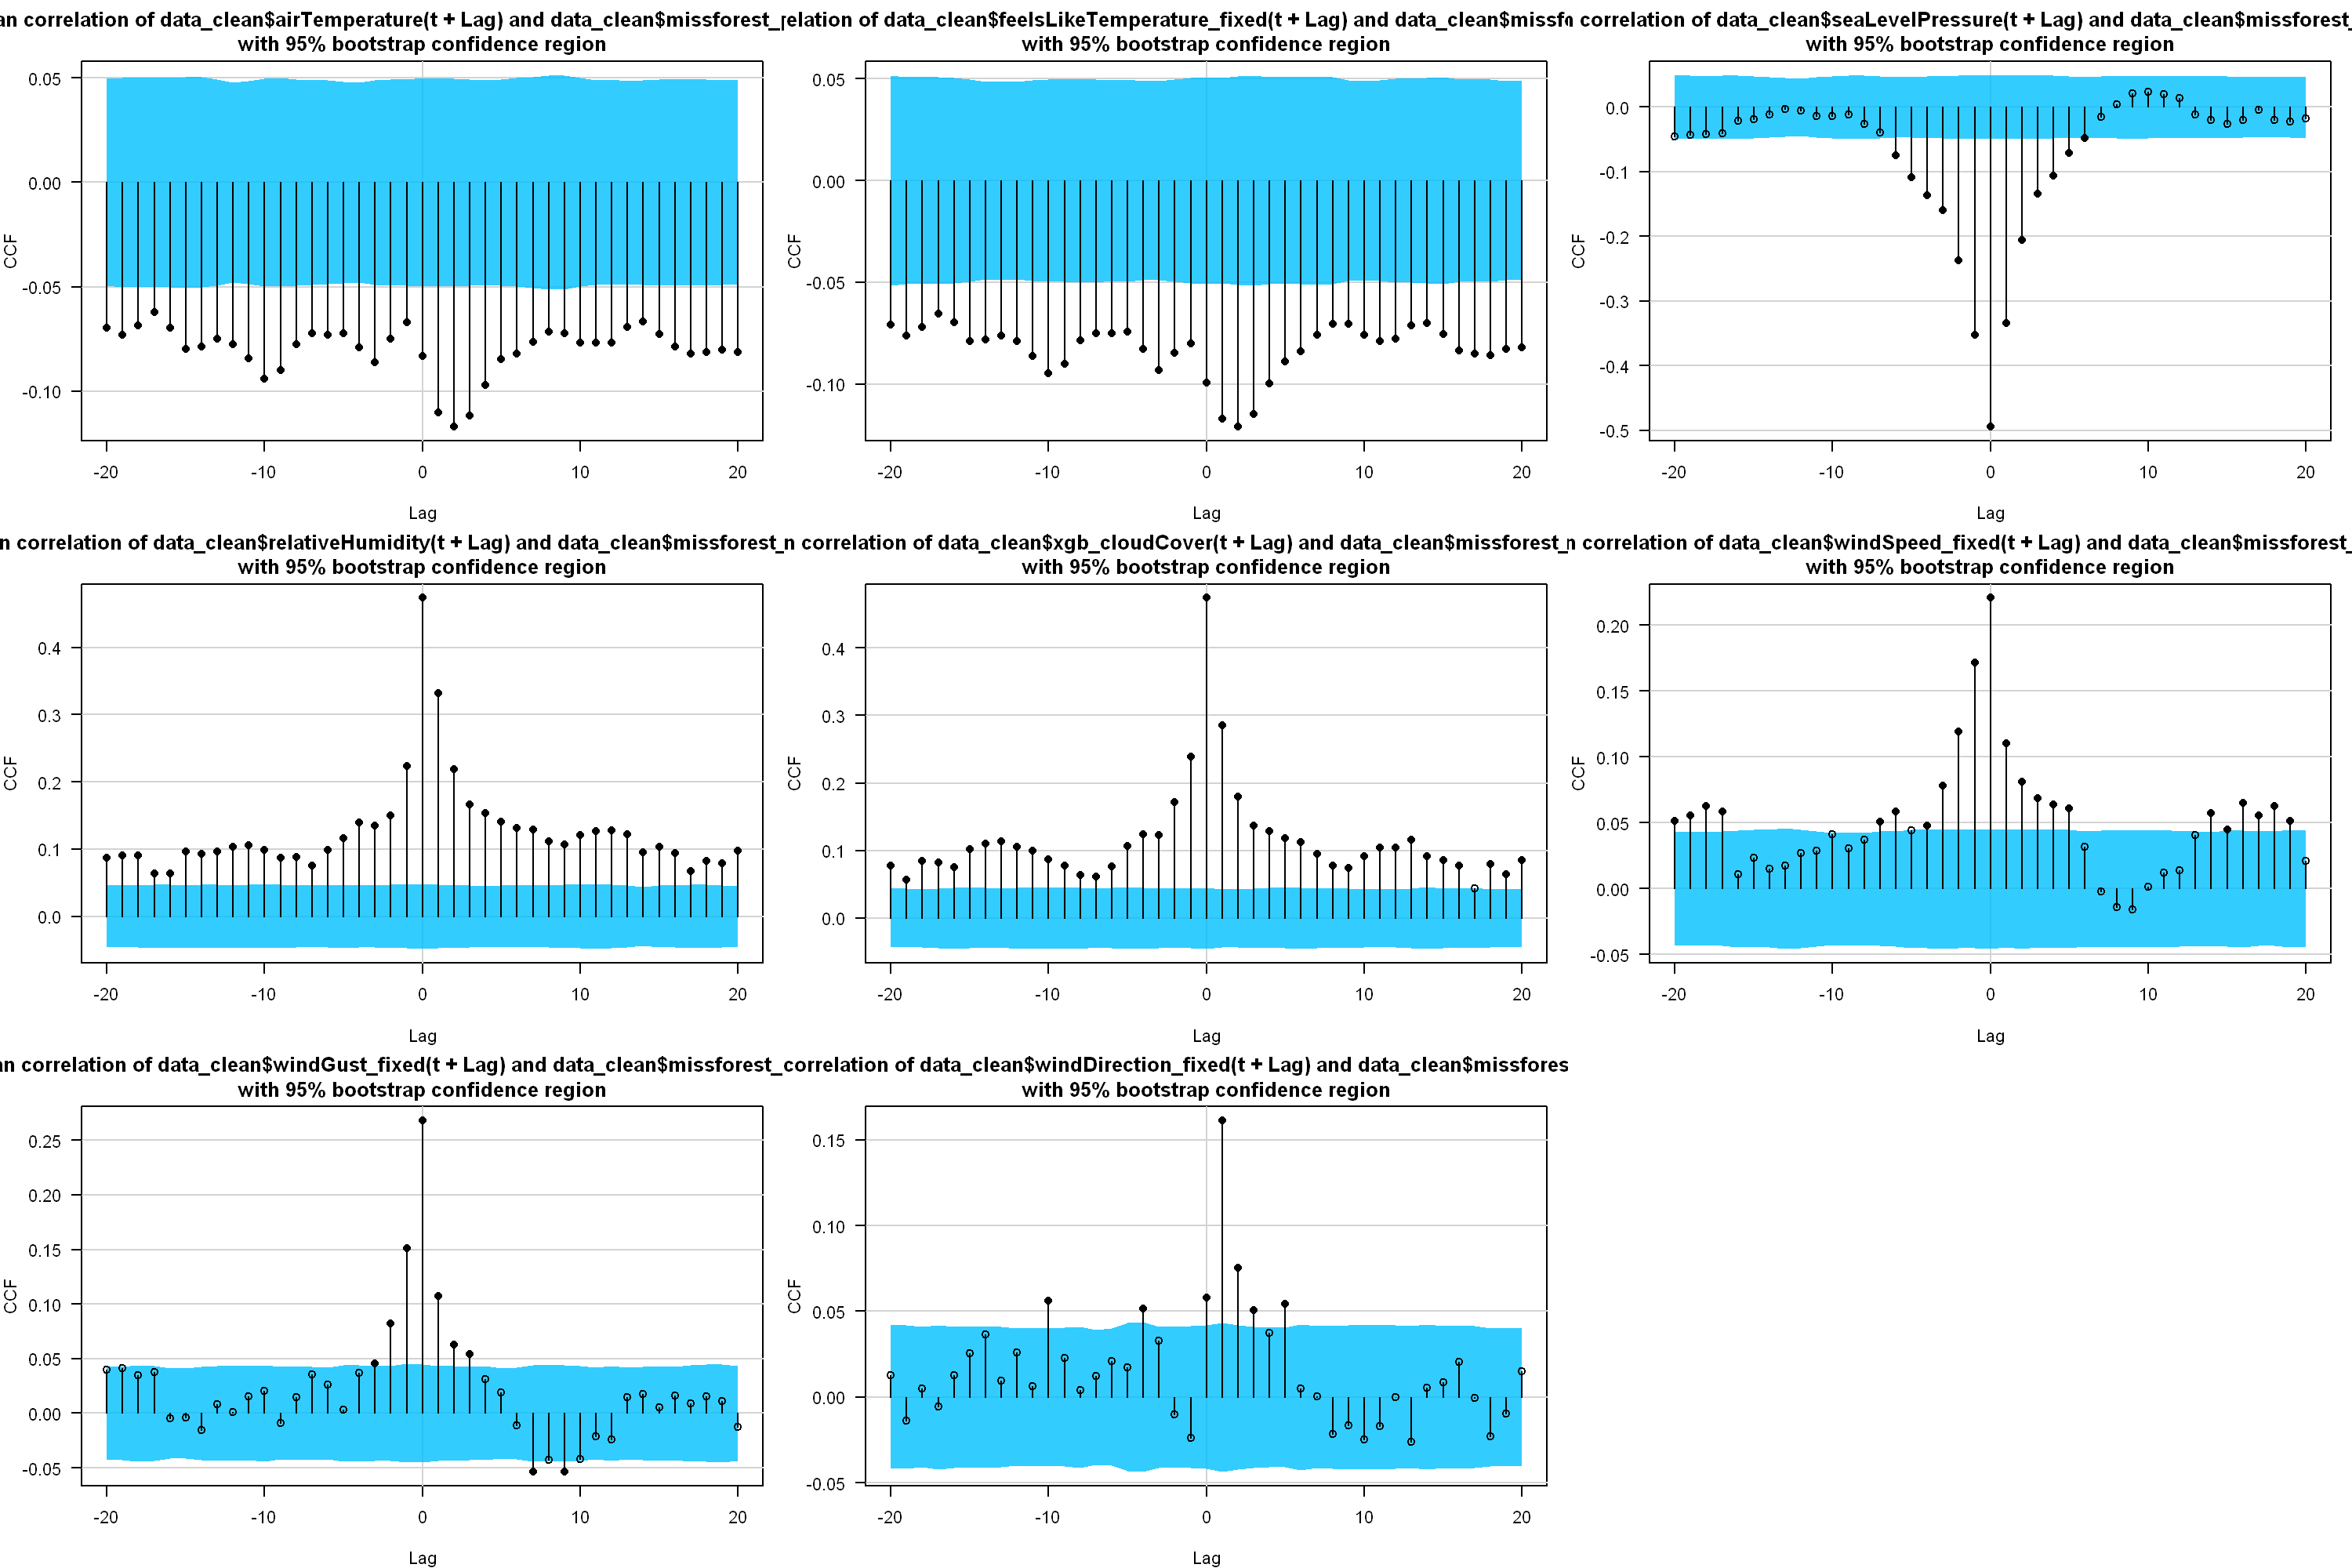

In [40]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 200)
par(mfrow = c(3, 3), mar = c(4, 4, 3, 1))

ccf_boot(data_clean$airTemperature, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$feelsLikeTemperature_fixed, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$seaLevelPressure, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$relativeHumidity, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$xgb_cloudCover, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$windSpeed_fixed, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$windGust_fixed, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$windDirection_fixed, data_clean$missforest_precipitation, lag.max = 20, plot = "Spearman")

par(mfrow = c(1, 1))

In [41]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

width_inch = 17 / 2.54
height_inch = width_inch * 0.75

png(filename = "cross_corr.png", width = width_inch, height = height_inch, units = "in", res = 300)
par(mfrow = c(3, 3), mar = c(3, 3, 3, 1), oma = c(2, 5, 4, 2))


plot_ccf_custom <- function(x, y, pavadinimas) {
  res <- ccf(x, y, lag.max = 14, plot = FALSE)
  
  plot(res, main = "", yaxt = 'n', ylab = "", cex.axis = 1, cex.lab = 1)
  title(main = pavadinimas, cex.main = 1.0)
  
  y_ticks <- axTicks(2)
  y_labels <- gsub("\\.", ",", sprintf("%.2f", y_ticks))

  axis(2, at = y_ticks, labels = y_labels, las = 1, cex.axis = 1)
}

plot_ccf_custom(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, "NO2 VCD")
plot_ccf_custom(data_clean$BrO, data_clean$missforest_precipitation, "BrO VCD")
plot_ccf_custom(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, "H2O")
plot_ccf_custom(data_clean$sia, data_clean$missforest_precipitation, "PM2,5 SIA")
plot_ccf_custom(data_clean$pm2p5, data_clean$missforest_precipitation, "PM2,5")
plot_ccf_custom(data_clean$pans, data_clean$missforest_precipitation, "PAN")
plot_ccf_custom(data_clean$nmvoc, data_clean$missforest_precipitation, "NMVO")
plot_ccf_custom(data_clean$nh3, data_clean$missforest_precipitation, "NH3")
plot_ccf_custom(data_clean$pm10, data_clean$missforest_precipitation, "PM10")

mtext("Kryžminės koreliacijos koeficientas", side = 2, line = 2, outer = TRUE, cex = 0.85)
mtext("Kryžminė koreliacija tarp kritulių ir taršos elementų", side = 3, line = 2, outer = TRUE, cex = 1.05)
par(mfrow = c(1, 1))

dev.off()

agg_record_70310356 
                  2

In [42]:
library(funtimes)

width_inch = 17 / 2.54
height_inch = width_inch * 0.6

png(filename = "cross_corr_NEW.png", width = width_inch, height = height_inch, units = "in", res = 300)
par(mfrow = c(3, 3), mar = c(2, 3.5, 2, 1), oma = c(2, 4, 3, 1))

plot_ccf_custom <- function(x, y, name) {
  boot_res <- ccf_boot(x, y, lag.max = 14, plot = "none", B = 1000)
  
  lags <- boot_res$Lag
  rS <- boot_res$r_S
  lower <- boot_res$lower_S
  upper <- boot_res$upper_S

  y_min <- min(lower, rS) * 1.1
  y_max <- max(upper, rS) * 1.1

  plot(lags, rS, type = "n", ylim = c(y_min, y_max),
       xaxt = 'n', yaxt = 'n', xlab = "", ylab = "", main = "")

  grid(nx = NA, ny = NULL, col = "gray90", lty = "dotted")
  
  lines(lags, lower, col = "blue", lty = 2)
  lines(lags, upper, col = "blue", lty = 2)
  abline(h = 0, col = "grey")
  
  segments(lags, 0, lags, rS, lwd = 1)
  
  significant <- rS > upper | rS < lower
  points(lags[significant], rS[significant], pch = 21, bg = "orange", cex = 0.85)
  
  axis(1, at = seq(-14, 14, by = 7), cex.axis = 1)
  y_ticks <- axTicks(2)
  y_labels <- gsub("\\.", ",", sprintf("%.2f", y_ticks))
  axis(2, at = y_ticks, labels = y_labels, las = 1, cex.axis = 1)
  
  title(main = name, cex.main = 1)
}

plot_ccf_custom(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, expression(NO[2]~VCD))
plot_ccf_custom(data_clean$BrO, data_clean$missforest_precipitation, expression(BrO~VCD))
plot_ccf_custom(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, expression(H[2]*O))
plot_ccf_custom(data_clean$sia, data_clean$missforest_precipitation, expression(PM[2.5]~SIA))
plot_ccf_custom(data_clean$pm2p5, data_clean$missforest_precipitation, expression(PM[2.5]))
plot_ccf_custom(data_clean$pans, data_clean$missforest_precipitation, expression(PAN))
plot_ccf_custom(data_clean$nmvoc, data_clean$missforest_precipitation, expression(NMVOC))
plot_ccf_custom(data_clean$nh3, data_clean$missforest_precipitation, expression(NH[3]))
plot_ccf_custom(data_clean$pm10, data_clean$missforest_precipitation, expression(PM[10]))

mtext("Ankstinys", side = 1, line = 0.5, outer = TRUE, cex = 0.85)
mtext("Spearman kryžminės koreliacijos koeficientas", side = 2, line = 2.5, outer = TRUE, cex = 0.85)
mtext("Kryžminė koreliacija", side = 3, line = 1, outer = TRUE, cex = 1.05)

dev.off()

agg_record_1803403292 
                    2

---

In [43]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

In [44]:
library(funtimes)

width_inch = 17 / 2.54
height_inch = width_inch * 1.2

png(filename = "cross_corr_all.png", width = width_inch, height = height_inch, units = "in", res = 300)
par(mfrow = c(6, 4), mar = c(2, 3.5, 2, 1), oma = c(2, 4, 3, 1))

plot_ccf_custom <- function(x, y, name) {
  boot_res <- ccf_boot(x, y, lag.max = 14, plot = "none", B = 1000)
  
  lags <- boot_res$Lag
  rS <- boot_res$r_S
  lower <- boot_res$lower_S
  upper <- boot_res$upper_S

  y_min <- min(lower, rS) * 1.1
  y_max <- max(upper, rS) * 1.1

  plot(lags, rS, type = "n", ylim = c(y_min, y_max),
       xaxt = 'n', yaxt = 'n', xlab = "", ylab = "", main = "")

  grid(nx = NA, ny = NULL, col = "gray90", lty = "dotted")
  
  lines(lags, lower, col = "blue", lty = 2)
  lines(lags, upper, col = "blue", lty = 2)
  abline(h = 0, col = "grey")
  
  segments(lags, 0, lags, rS, lwd = 1)
  
  significant <- rS > upper | rS < lower
  points(lags[significant], rS[significant], pch = 21, bg = "orange", cex = 0.85)
  
  axis(1, at = seq(-14, 14, by = 7), cex.axis = 1)
  y_ticks <- axTicks(2)
  y_labels <- gsub("\\.", ",", sprintf("%.2f", y_ticks))
  axis(2, at = y_ticks, labels = y_labels, las = 1, cex.axis = 1)
  
  title(main = name, cex.main = 1)
}


plot_ccf_custom(data_clean$airTemperature, data_clean$missforest_precipitation, expression(Oro~temperatūra))
plot_ccf_custom(data_clean$feelsLikeTemperature_fixed, data_clean$missforest_precipitation, expression(Juntamoji~temp.))
plot_ccf_custom(data_clean$seaLevelPressure, data_clean$missforest_precipitation, expression(Slėgis~jūros~lygyje))
plot_ccf_custom(data_clean$relativeHumidity, data_clean$missforest_precipitation, expression(Santykinis~oro~drėgnis))
plot_ccf_custom(data_clean$xgb_cloudCover, data_clean$missforest_precipitation, expression(Debesuotumas))
plot_ccf_custom(data_clean$windSpeed_fixed, data_clean$missforest_precipitation, expression(Vėjo~greitis))
plot_ccf_custom(data_clean$windGust_fixed, data_clean$missforest_precipitation, expression(Vėjo~gūsis))
plot_ccf_custom(data_clean$windDirection_fixed, data_clean$missforest_precipitation, expression(Vėjo~kryptis))

plot_ccf_custom(data_clean$absorbing_aerosol_index, data_clean$missforest_precipitation, expression(AAI))
plot_ccf_custom(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, expression(NO[2]~VCD))
plot_ccf_custom(data_clean$stratospheric_NO2_column_number_density, data_clean$missforest_precipitation, expression(Stratosferos~NO[2]~VCD))
plot_ccf_custom(data_clean$NO2_slant_column_number_density, data_clean$missforest_precipitation, expression(NO[2]~SCD))
plot_ccf_custom(data_clean$tropopause_pressure, data_clean$missforest_precipitation, expression(Tropopauzės~slėgis))
plot_ccf_custom(data_clean$BrO, data_clean$missforest_precipitation, expression(BrO~VCD))
plot_ccf_custom(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, expression(H[2]*O))
plot_ccf_custom(data_clean$NO2, data_clean$missforest_precipitation, expression(NO[2]~(Go)~VCD))
plot_ccf_custom(data_clean$O3, data_clean$missforest_precipitation, expression(O[3]~VCD))
plot_ccf_custom(data_clean$dust, data_clean$missforest_precipitation, expression(Dulkės))
plot_ccf_custom(data_clean$sia, data_clean$missforest_precipitation, expression(PM[2.5]~SIA))
plot_ccf_custom(data_clean$pm2p5, data_clean$missforest_precipitation, expression(PM[2.5]))
plot_ccf_custom(data_clean$pans, data_clean$missforest_precipitation, expression(PAN))
plot_ccf_custom(data_clean$nmvoc, data_clean$missforest_precipitation, expression(NMVOC))
plot_ccf_custom(data_clean$nh3, data_clean$missforest_precipitation, expression(NH[3]))
plot_ccf_custom(data_clean$pm10, data_clean$missforest_precipitation, expression(PM[10]))


mtext("Ankstinys", side = 1, line = 0.5, outer = TRUE, cex = 0.85)
mtext("Spearman kryžminės koreliacijos koeficientas", side = 2, line = 2.5, outer = TRUE, cex = 0.85)
mtext("Kryžminė koreliacija", side = 3, line = 1, outer = TRUE, cex = 1.05)

dev.off()

agg_record_1200979955 
                    2

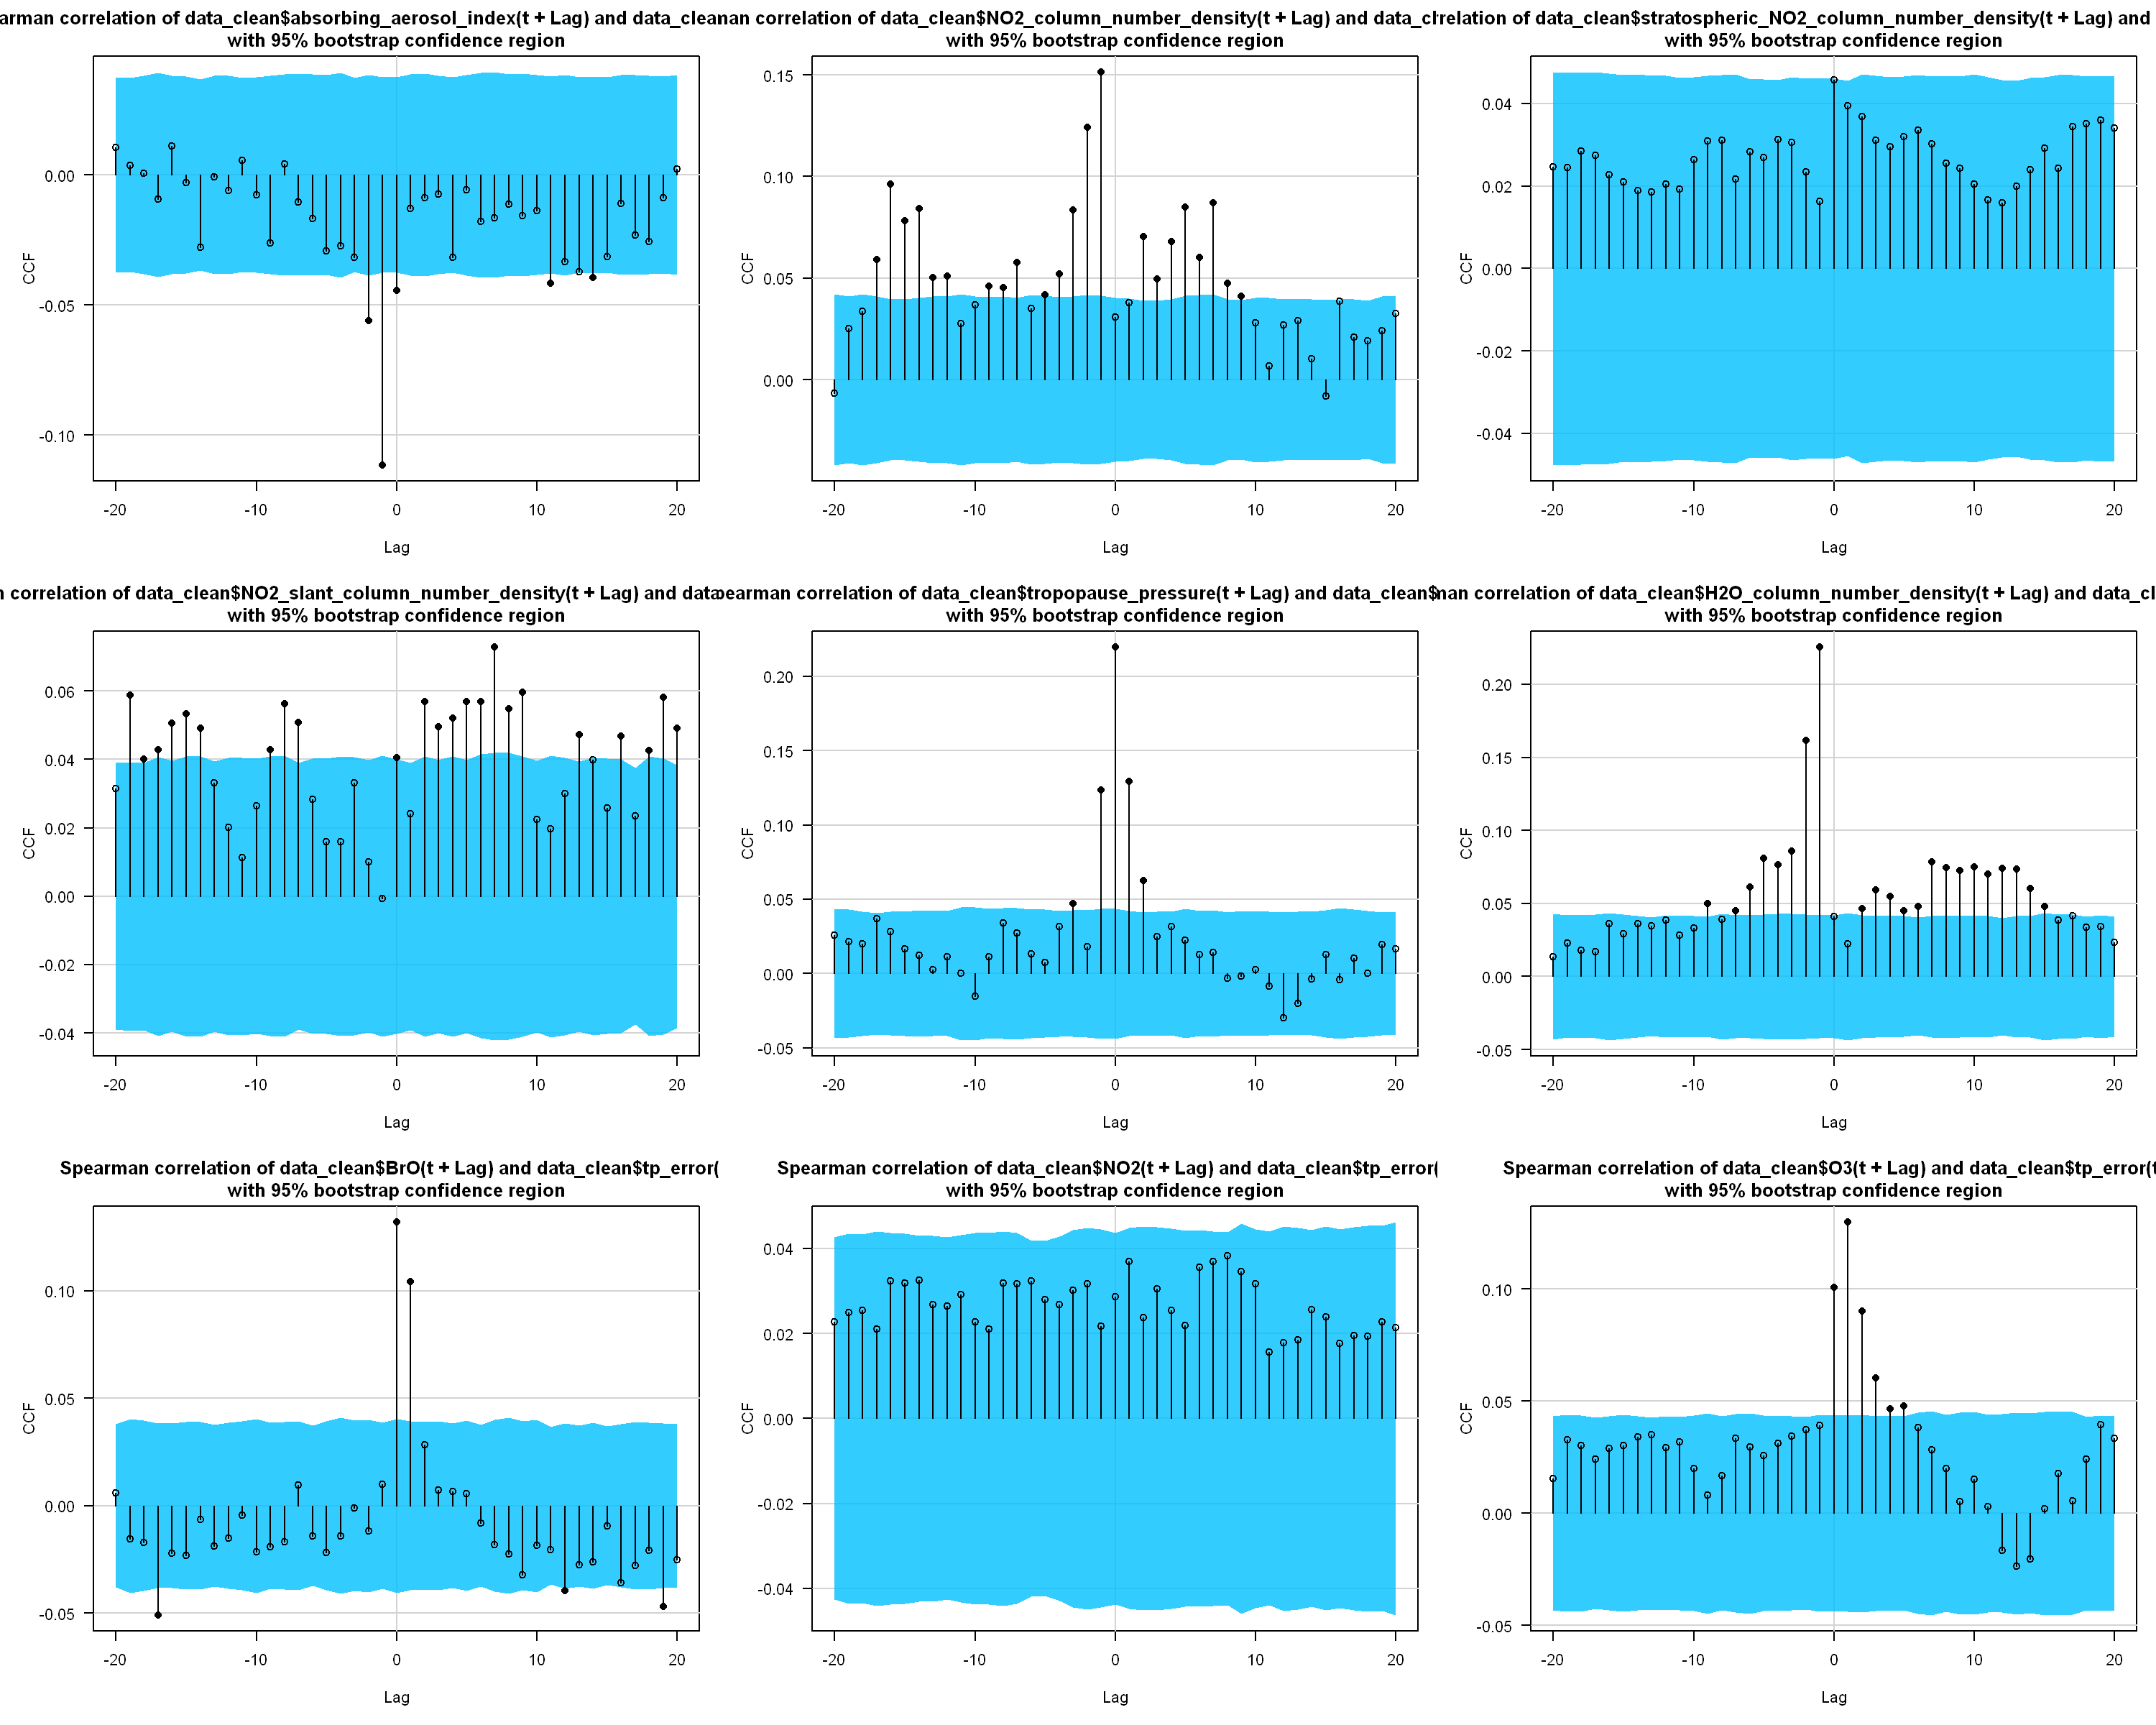

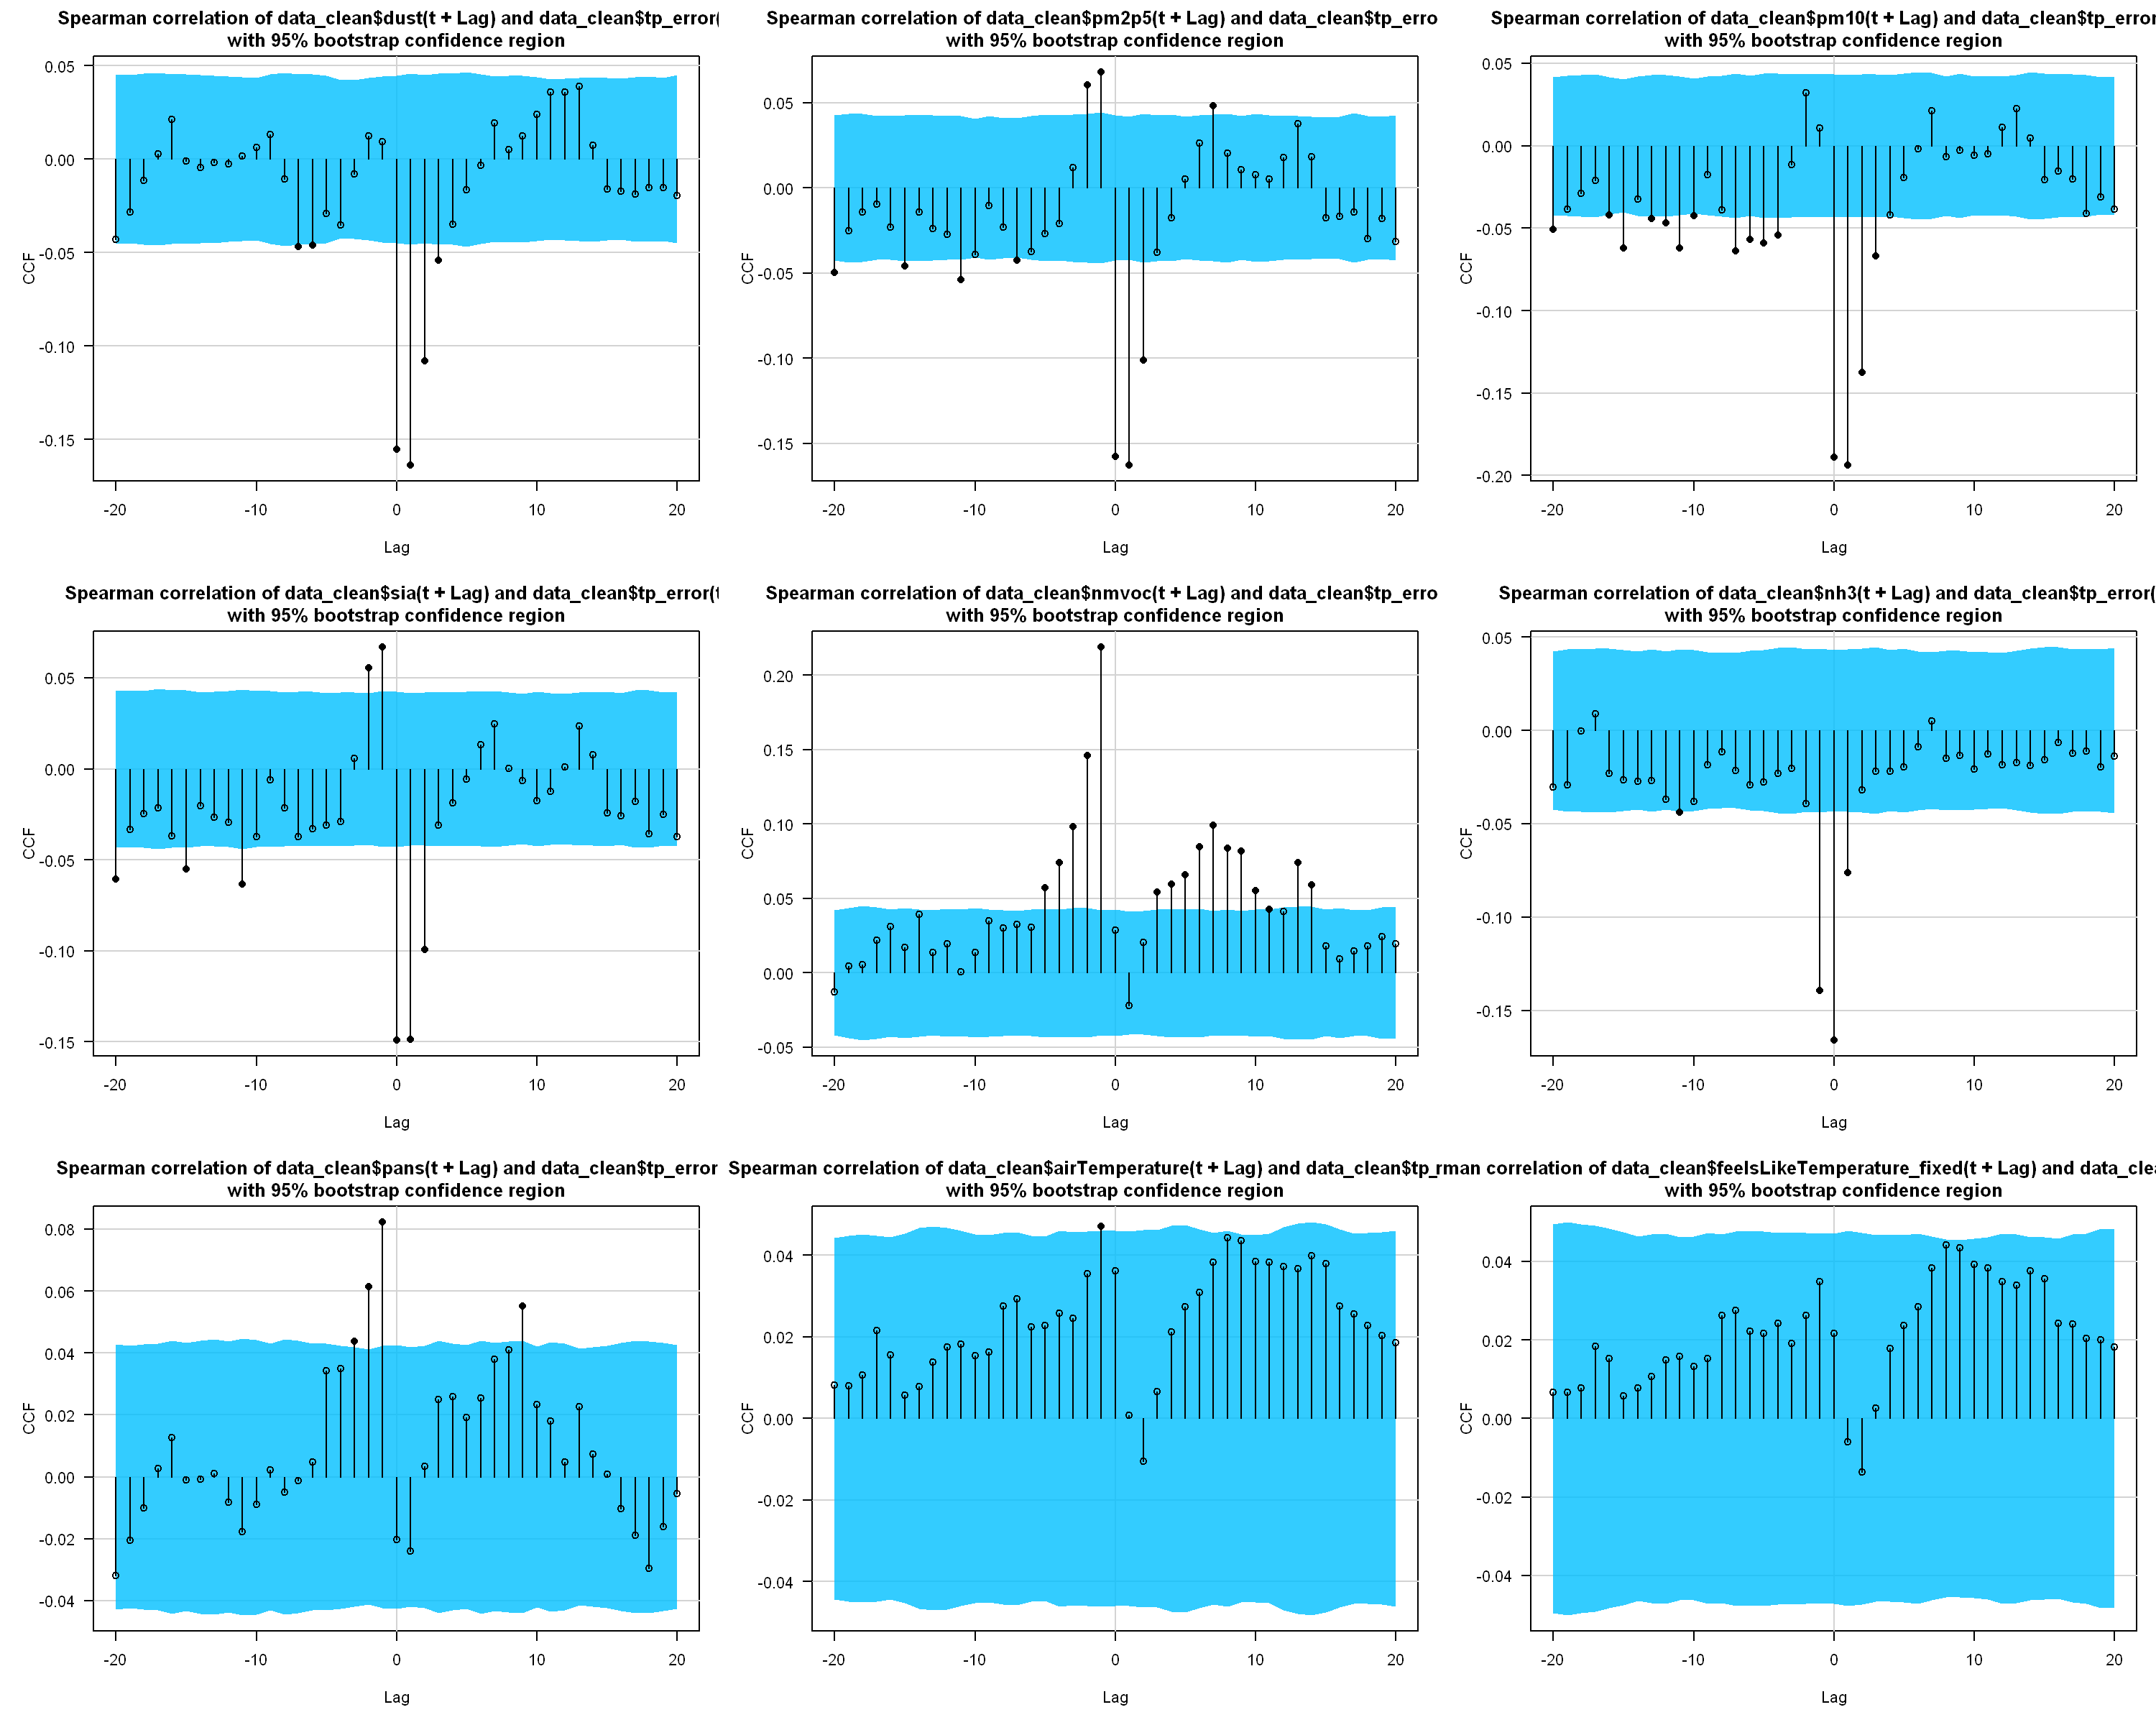

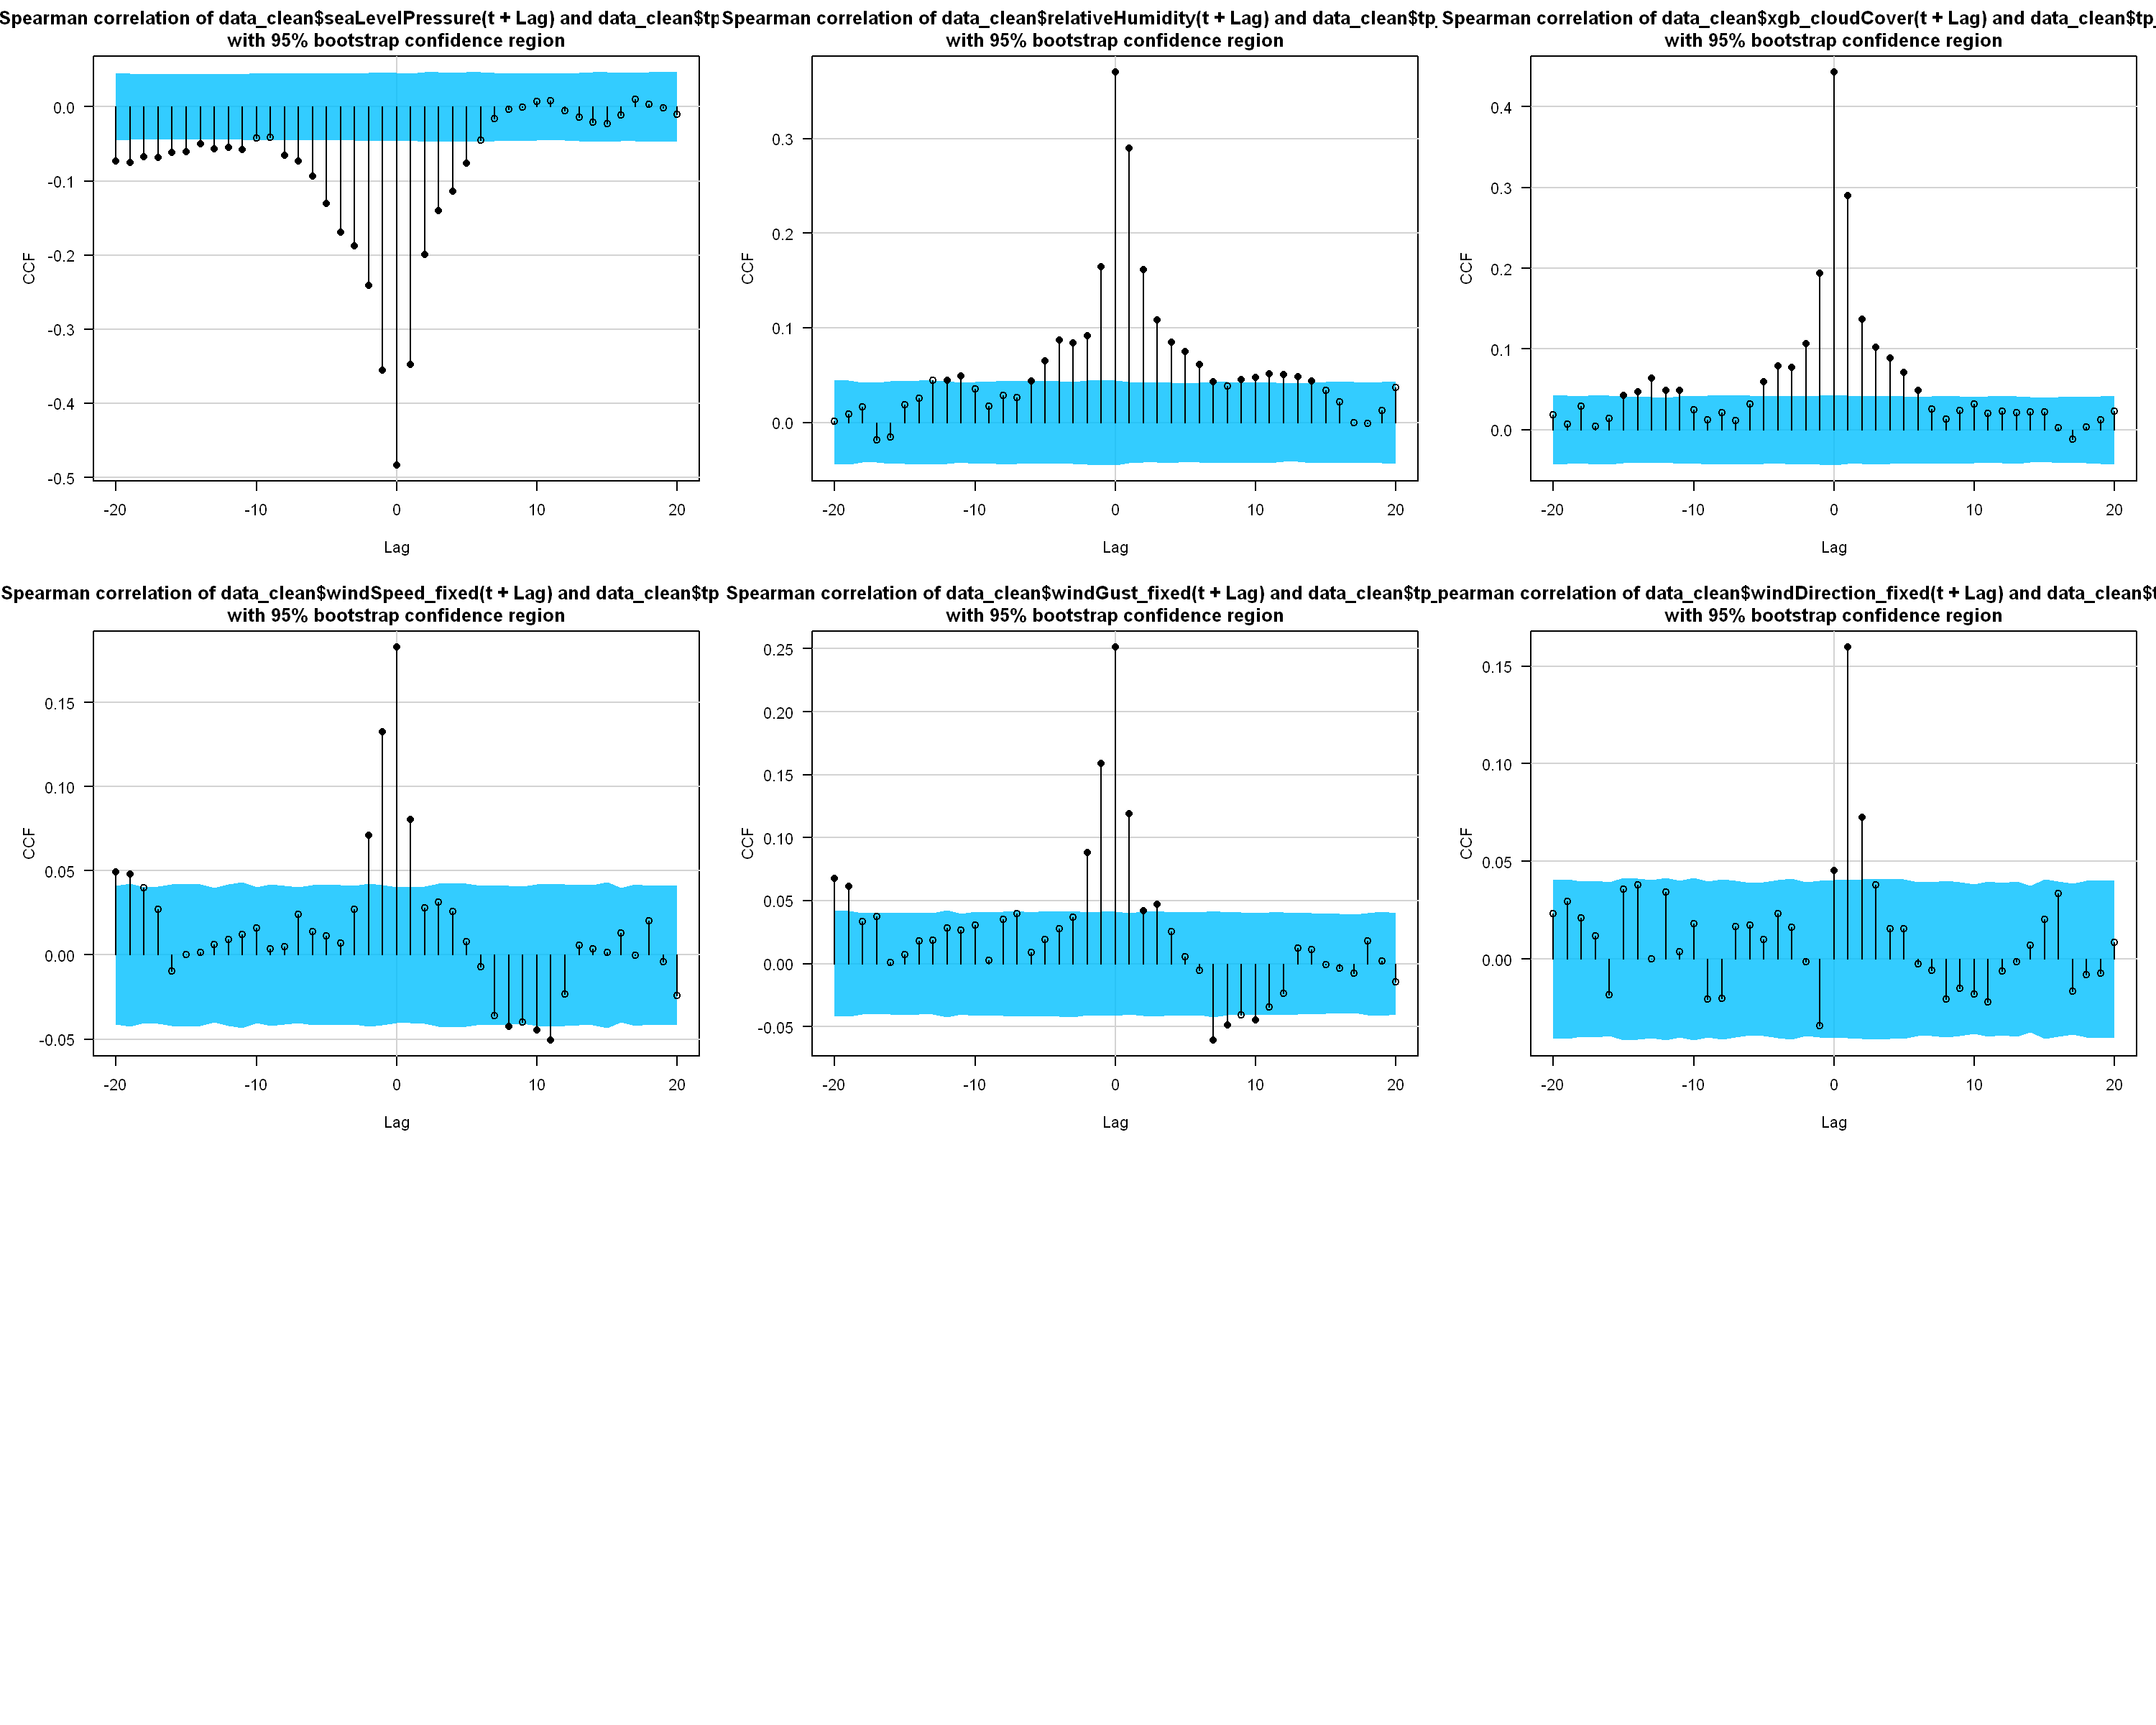

In [45]:
options(repr.plot.width = 15, repr.plot.height = 12, repr.plot.res = 200)
par(mfrow = c(3, 3), mar = c(5, 5, 3, 1))

ccf_boot(data_clean$absorbing_aerosol_index, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$NO2_column_number_density, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$stratospheric_NO2_column_number_density, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$NO2_slant_column_number_density, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$tropopause_pressure, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$H2O_column_number_density, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$BrO, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$NO2, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$O3, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$dust, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$pm2p5, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$pm10, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$sia, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$nmvoc, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$nh3, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$pans, data_clean$tp_error, lag.max = 20, plot = "Spearman")


ccf_boot(data_clean$airTemperature, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$feelsLikeTemperature_fixed, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$seaLevelPressure, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$relativeHumidity, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$xgb_cloudCover, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$windSpeed_fixed, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$windGust_fixed, data_clean$tp_error, lag.max = 20, plot = "Spearman")
ccf_boot(data_clean$windDirection_fixed, data_clean$tp_error, lag.max = 20, plot = "Spearman")

par(mfrow = c(1, 1))

-----

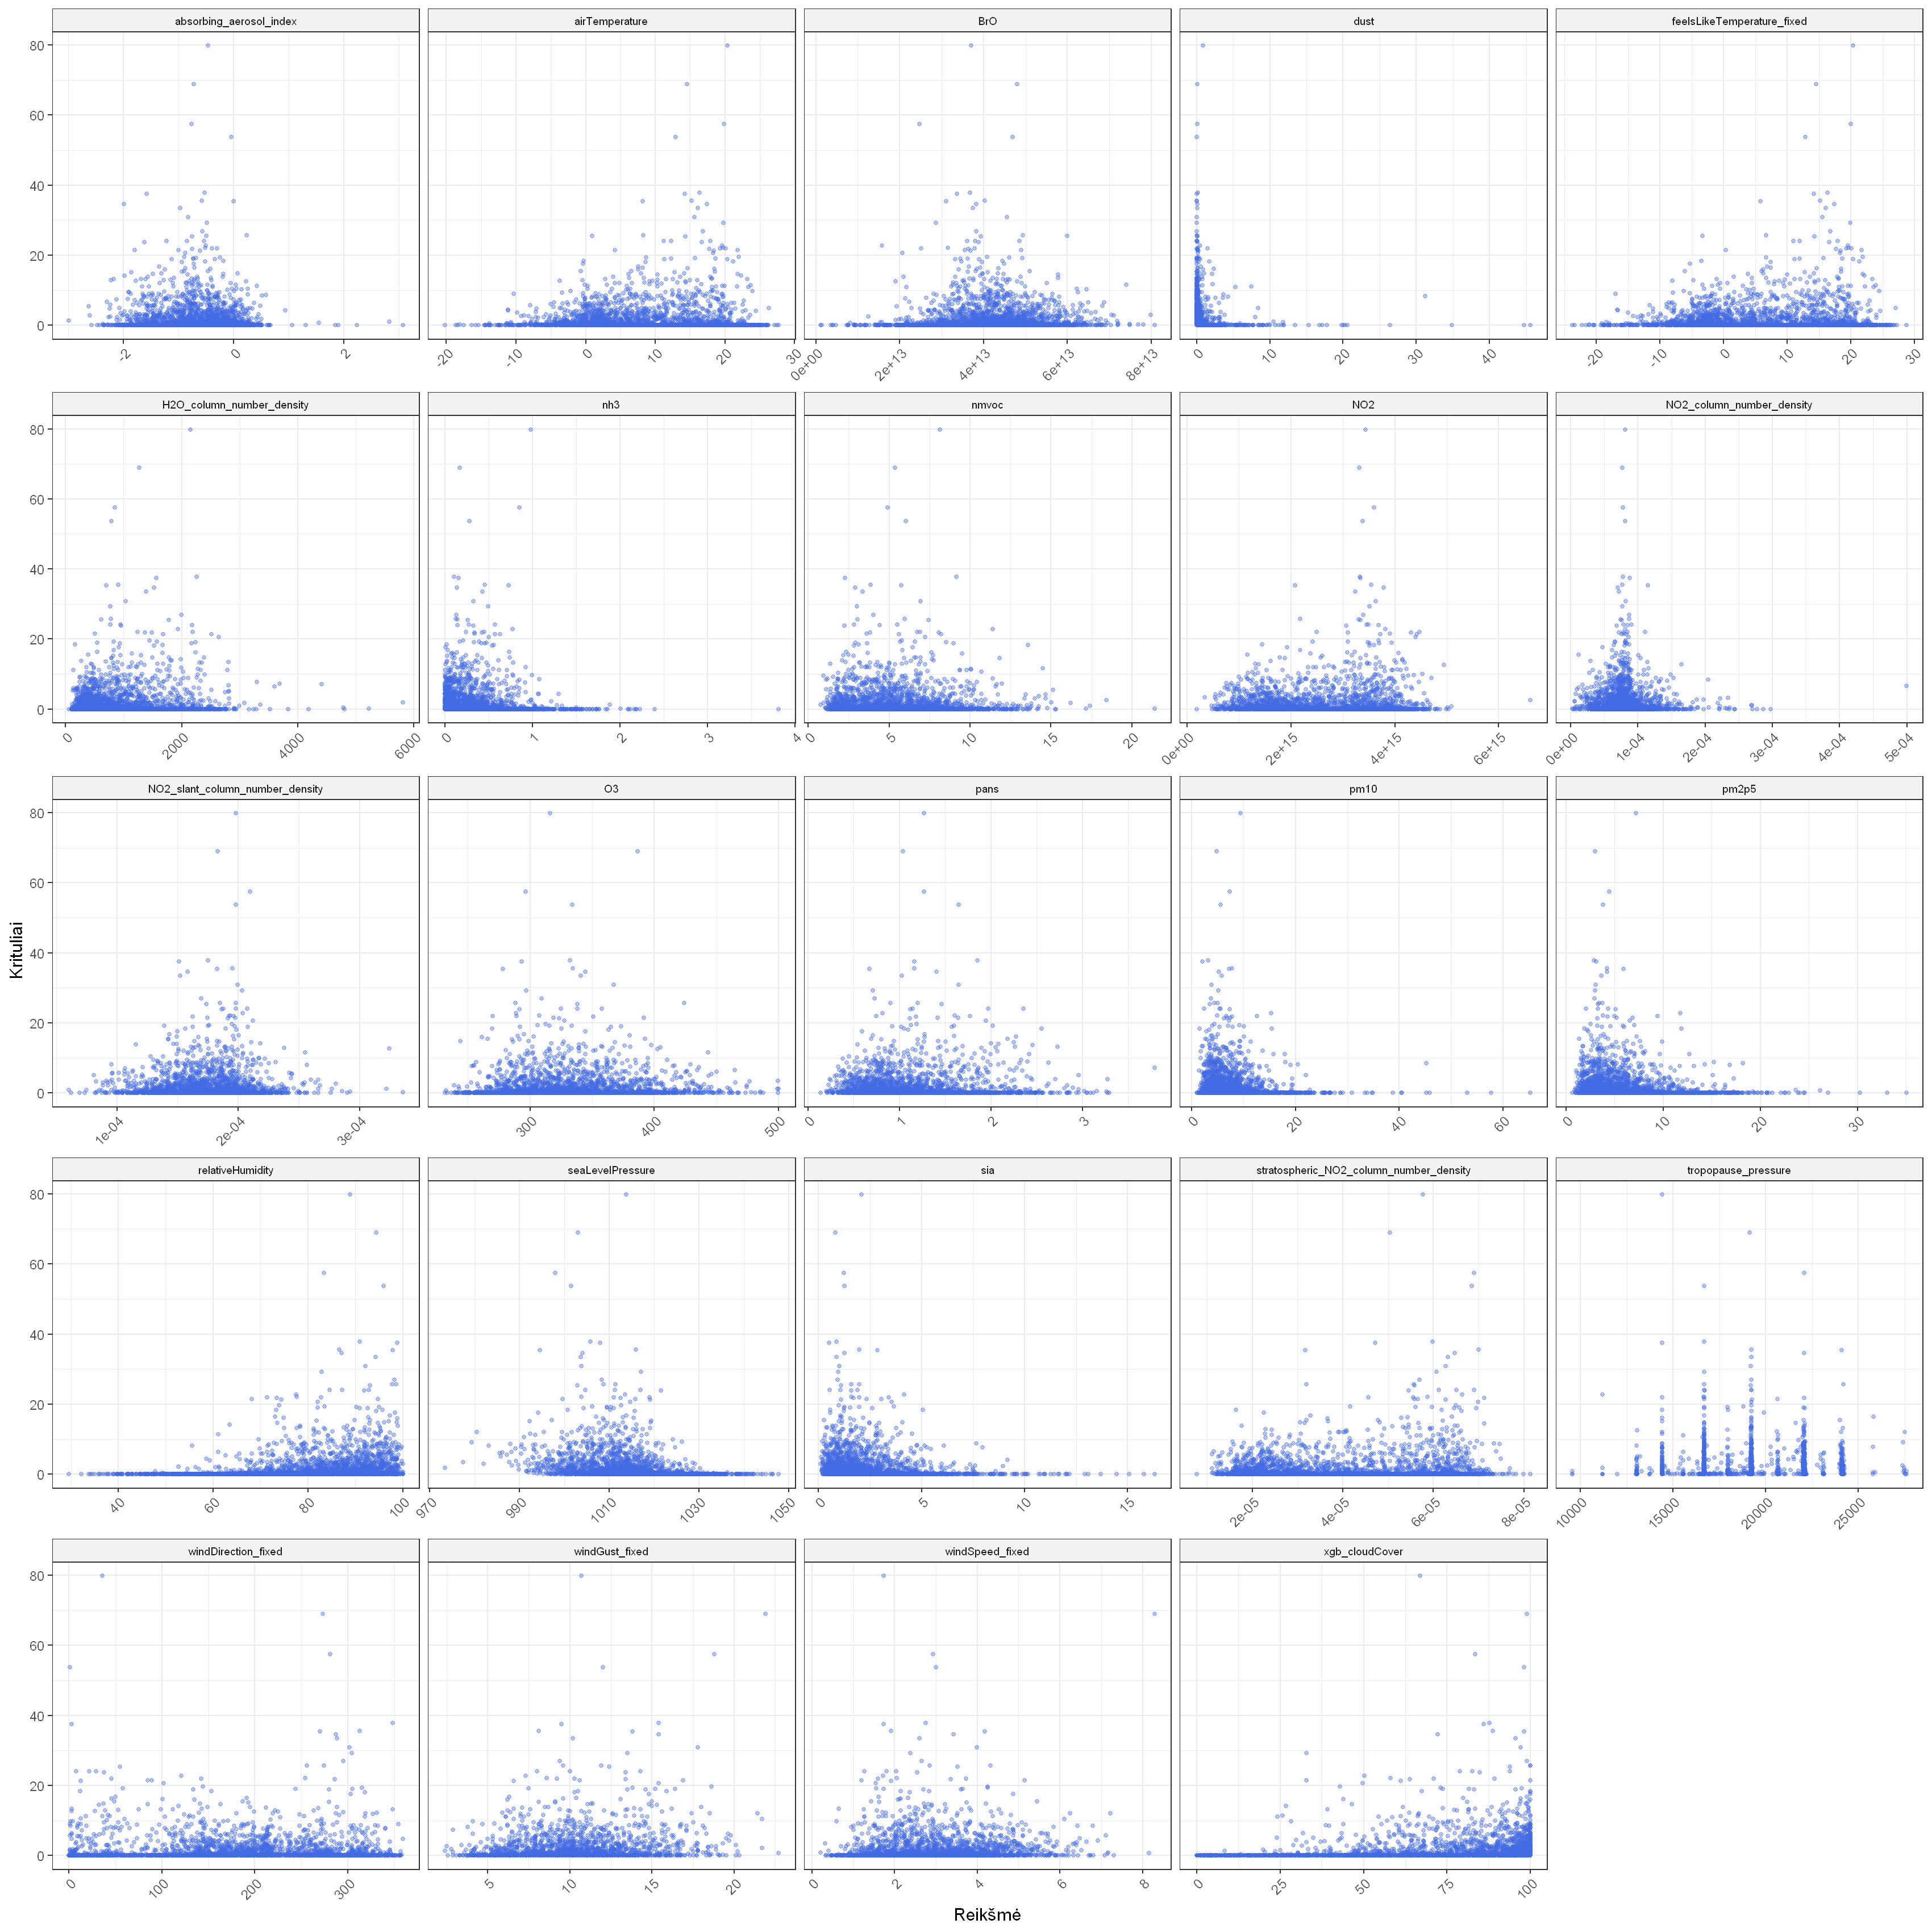

In [46]:
options(repr.plot.width = 17, repr.plot.height = 17, repr.plot.res = 200)
data_clean %>%
  dplyr::select(where(is.numeric)) %>%
  dplyr::select(-tp, -t2m, -tp_lag, -tp_error) %>%
  pivot_longer(cols = -`missforest_precipitation`, 
               names_to = "variable", 
               values_to = "value") %>%
  ggplot(aes(x = value, y = `missforest_precipitation`)) +
  geom_point(alpha = 0.4, size = 0.95, color = "royalblue") +
  facet_wrap(~variable, scales = "free_x", ncol = 5) +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(size = 7),
    axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Reikšmė",
       y = "Krituliai")

#ggsave(filename = "sklaida.png", width = 6.7, height = 4, units = "in", dpi = 300)